# Bayesian BLP: Structural Demand Estimation on Aggregate Market Shares


In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import norm, qmc

from pymc_marketing.customer_choice import BayesianBLP, generate_blp_panel

warnings.filterwarnings("ignore")
az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 5]
plt.rcParams["figure.dpi"] = 100
%config InlineBackend.figure_format = 'retina'

## The aggregate-data problem

You have weekly market-share data for a category. You want to know: if I raise the price of product A by 10%, how much share moves to product B versus the outside good? Standard regression on aggregate shares conflates two quantities: the average consumer's price sensitivity, and the *distribution* of price sensitivity across consumers. Conflate them and the same 10% hike predicts the wrong substitution pattern in every market that has a different mix of price-sensitive and price-insensitive buyers.

A short example. Market A has 40% share for sugary cereal at average income \$30k. Market B has 60% share at average income \$50k. A naïve read says higher income drives sugary cereal sales. Within each market the relationship may reverse. The market is a confounder; aggregation hides which way the within-market effect runs. This is the ecological fallacy.

## What BLP does

BLP estimates the *distribution* of consumer preferences most consistent with the observed aggregate shares. The estimator integrates over latent taste types and asks the Bayesian question: which preference distribution, propagated through a discrete-choice utility model, reproduces what we see in the data? With the distribution in hand, counterfactual prices feed through the same mechanism and give substitution patterns that respect both the average effect and the heterogeneity.


In [2]:
# --- Generate Halton draws ---
sampler_halton = qmc.Halton(d=3, scramble=True)
u = sampler_halton.random(100)

# Avoid infinities in inverse CDF
eps = np.finfo(np.float64).tiny
u = np.clip(u, eps, 1.0 - eps)

# Transform to Gaussian
z = norm.ppf(u)

# IID uniform for comparison
rand = np.random.rand(100, 3)

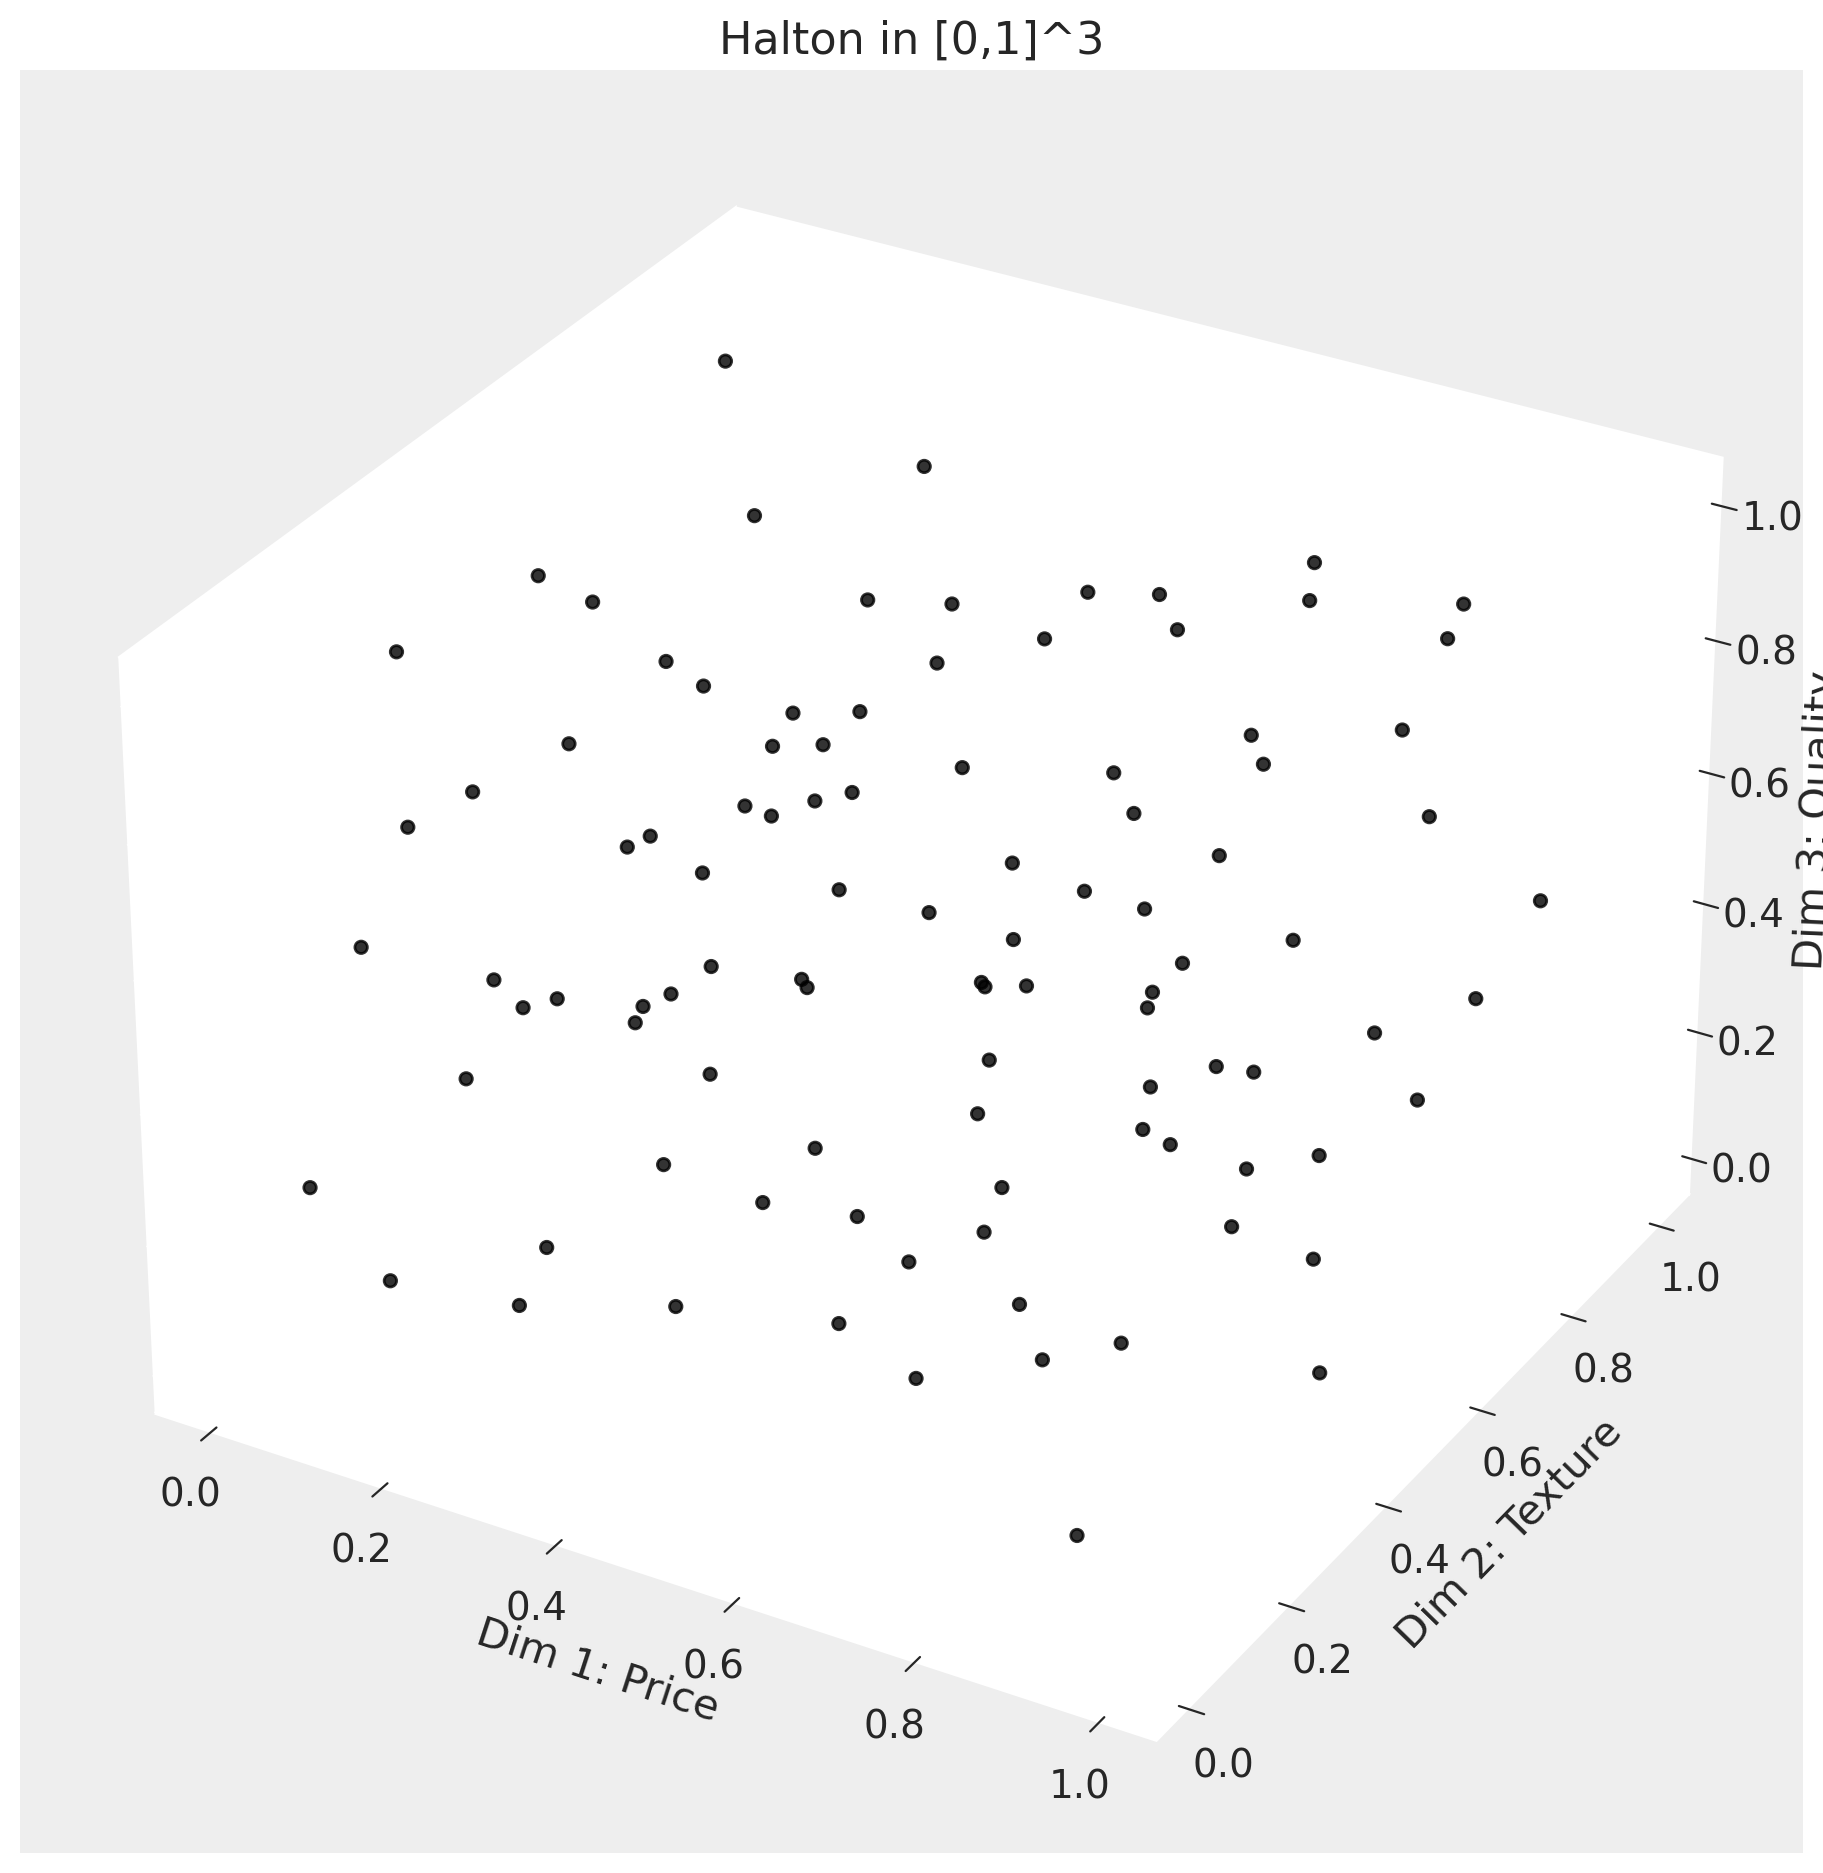

In [3]:
# --- Create figure layout ---
fig = plt.figure(figsize=(9, 14))
ax = fig.add_subplot(projection="3d")

# Scatter (make it pop)
ax.scatter(u[:, 0], u[:, 1], u[:, 2], s=20, color="black", alpha=0.8)

# White panes
ax.xaxis.set_pane_color((1, 1, 1, 1))
ax.yaxis.set_pane_color((1, 1, 1, 1))
ax.zaxis.set_pane_color((1, 1, 1, 1))

# Light grid
ax.grid(True, color="0.85", linewidth=0.8)

# Axis labels
ax.set_xlabel("Dim 1: Price")
ax.set_ylabel("Dim 2: Texture")
ax.set_zlabel("Dim 3: Quality")
ax.set_title("Halton in [0,1]^3")

plt.show()

## Halton draws

The integral over consumer taste types has no closed form, so we approximate it with a fixed grid of draws. Owen-scrambled Halton draws fill a D-dimensional cube more evenly than the same number of pseudo-random draws (figure below), which means fewer draws for a given accuracy. We treat these draws as data: the model sees the same Halton points on every iteration and learns which taste types are most consistent with the observed shares.


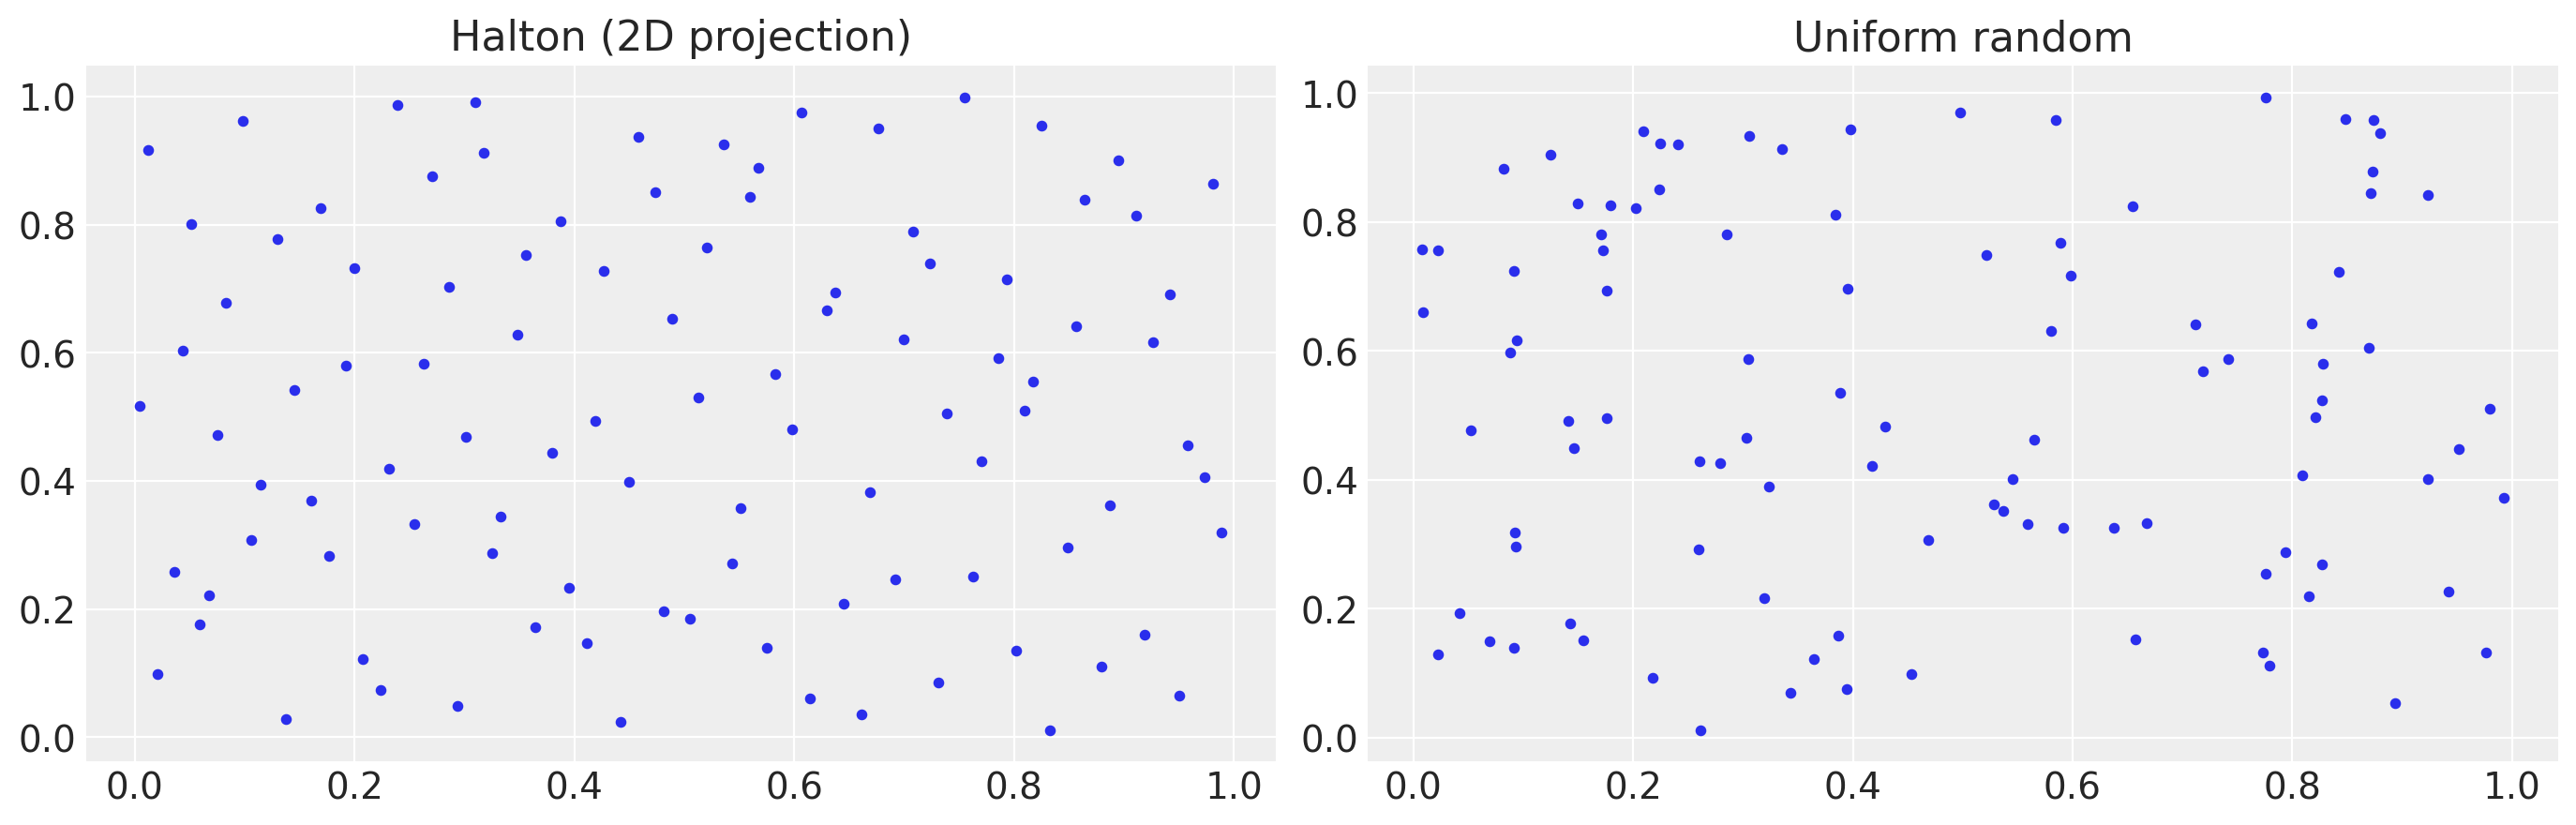

In [4]:
fig = plt.figure(figsize=(20, 8))

# ========== 3. Comparison with random ==========
ax4 = fig.add_subplot(231)
ax4.scatter(u[:, 0], u[:, 1], s=10)
ax4.set_title("Halton (2D projection)")

ax5 = fig.add_subplot(232)
ax5.scatter(rand[:, 0], rand[:, 1], s=10)
ax5.set_title("Uniform random");

The Halton grid feeds the share integral the model evaluates at every draw of the parameters:

$$
\hat{s}_{jm} =
\int_{\mathbb{R}^D}
\frac{\exp(\delta_{jm} + \mu_{ijm})}
     {1 + \sum_{k=1}^{J} \exp(\delta_{km} + \mu_{ikm})}
\; dF(\bm{\nu}_i; \mathbf{0}, \mathbf{I}_D)
$$

The mean utility and the consumer-level deviation are

$$
\delta_{jm} = \alpha_{r(m)} \, p_{jm} + \mathbf{x}_{jm}'\bm{\beta}_{r(m)} + \xi_{jm}
$$

$$
\mu_{ijm} = \sum_{d=1}^{D} \sigma_d \cdot \nu_{id} \cdot c_{jmd}
$$

where $c_{jmd}$ is the value of the $d$-th `random_coef_on` covariate for product $j$ in market $m$ (price, or any product characteristic the user passes). $\delta_{jm}$ carries the average preferences, identified by $\alpha$ and $\beta$; $\mu_{ijm}$ carries the consumer-level departure from those averages, scaled by $\sigma_d$ along each random-coefficient dimension.


## When to use this model

PyMC-Marketing ships three discrete-choice model families. Pick the one that matches your data shape and question:

| Model | Data shape | What it answers |
|---|---|---|
| **MNL / MixedLogit** | Individual choice occasions | Who chose what, and why? |
| **MVITS** | Aggregate share time series | What happened when brand X launched? |
| **BayesianBLP** *(this notebook)* | Aggregate share panels | What would happen if I changed price? |

**BayesianBLP** is a structural random-coefficients logit on aggregate shares: the Bayesian reformulation of Berry, Levinsohn & Pakes (1995) following Jiang, Manchanda & Rossi (2009). Reach for it when:

- You have **aggregate market shares** (not individual transactions).
- You need structurally grounded **cross-price substitution patterns**.
- Prices may be **endogenous** (set by firms who observe unobserved demand shocks)
  and you have **cost or rival-characteristic instruments** to correct the bias.
- You want **full posterior uncertainty** on elasticities and counterfactual shares,
  with correct propagation through the structural demand model.

The Bayesian formulation replaces the classical BLP contraction mapping + GMM with a joint posterior over preference parameters and the latent demand shocks $\xi_{jt}$. Hierarchical pooling across regions becomes cheap, and the credible intervals stay honest under weak instruments.


## 1. Synthetic data: a BLP-style aggregate share panel

We use `generate_blp_panel` to create a synthetic panel with known true parameters. The data-generating process produces a joint $(\eta_{jt}, \tilde{\xi}_{jt})$ shock so that prices are endogenous: estimation without instruments will bias the price coefficient toward zero.

The returned DataFrame is in long format: one row per (market, product), with the outside good as a row labelled `'outside'`. The `truth` dictionary records the DGP parameters we will try to recover.

**Market semantics.** A BLP "market" is a `(region, period)` cell: the unit at which shares and prices are observed. The model treats markets as exchangeable unless you tell it otherwise. Pass `time_col="period"` to `BayesianBLP` to expose `period` as a first-class coordinate. Then `counterfactual_shares` and `elasticities` accept `periods=` / `regions=` coord-label arguments so you can phrase questions like "raise prod_0 price by 10% in periods 10–20" directly. This notebook turns that on at construction so the time-targeted counterfactual section near the end just works.


In [5]:
df, truth = generate_blp_panel(
    T=40,  # markets (think: 40 weeks)
    J=3,  # inside products
    K=2,  # product characteristics
    L=2,  # instruments per product
    true_alpha=-2.0,
    true_beta=np.array([0.8, 1.2]),
    sigma_alpha=0.5,  # std of consumer price heterogeneity
    sigma_beta=np.array([0.4, 0.5]),  # std of consumer characteristic heterogeneity
    instrument_strength=0.7,  # first-stage R² ≈ 0.49
    price_xi_corr=0.6,  # endogeneity severity
    market_size=4_000,
    n_dgp_draws=3_000,
    random_seed=42,
    return_truth=True,
)

print(
    f"Panel: {df['market'].nunique()} markets × {len(truth['characteristic_cols'])} "
    f"characteristics + {len(truth['instrument_cols'])} instruments"
)
print(f"True alpha (price):  {truth['alpha']:.3f}")
print(f"True beta:           {truth['beta']}")
print(f"True sigma_alpha:    {truth['sigma_alpha']:.3f}")
print(f"True sigma_beta:     {truth['sigma_beta']}")
print(f"Outside share mean:  {df[df['product'] == 'outside']['share'].mean():.3f}")

Panel: 40 markets × 2 characteristics + 2 instruments
True alpha (price):  -2.000
True beta:           [0.8 1.2]
True sigma_alpha:    0.500
True sigma_beta:     [0.4 0.5]
Outside share mean:  0.661


In [6]:
df.head(8)

,region,market,period,product,share,n,price,x_0,x_1,z_0,z_1
0,r0,0,0,outside,0.93125,4000,0.000000,0.0,0.000000,0.000000,0.000000
1,r0,0,0,prod_0,0.00075,4000,4.124200,0.0,-0.863345,0.006339,2.597674
2,r0,0,0,prod_1,0.03800,4000,1.210960,0.0,-0.147529,0.223080,1.433215
3,r0,0,0,prod_2,0.03000,4000,1.987674,0.0,-0.152523,0.091520,0.580777
4,r0,1,1,outside,0.55250,4000,0.000000,0.0,0.000000,0.000000,0.000000
5,r0,1,1,prod_0,0.39900,4000,0.929217,1.0,0.383394,-0.056783,-0.170408
6,r0,1,1,prod_1,0.04725,4000,2.298272,1.0,0.999824,-0.779482,0.430301
7,r0,1,1,prod_2,0.00125,4000,3.006346,0.0,-1.058536,-0.851537,0.665585


## 2. Model specification and prior predictive check

We instantiate `BayesianBLP` with:
- `random_coef_on=["price", "x_0", "x_1"]`: a 3-dimensional consumer taste vector $\bm{\nu}_i \in \mathbb{R}^3$. Each component is a standardised draw that scales heterogeneity on one covariate: price sensitivity ($\sigma_\alpha$), and the two product characteristics ($\sigma_{\beta_0}, \sigma_{\beta_1}$). With 3 random coefficients the model fits genuine multi-dimensional taste profiles rather than collapsing to scalar price sensitivity.
- `instruments=truth['instrument_cols']`: enables the price-endogeneity correction.
- `n_mc_draws=200`: Owen-scrambled Halton draws filling $[0,1]^3$ and mapped to $\mathcal{N}(0, I_3)$. The rule of thumb is roughly 100 draws per random-coefficient dimension; we use 200 for $D=3$.

A prior predictive check confirms that the priors put mass on shares plausible for scanner data (all predicted shares fall in [0, 1] and sum to 1 per market).


In [7]:
model = BayesianBLP(
    market_data=df,
    characteristics=truth["characteristic_cols"],
    instruments=truth["instrument_cols"],
    random_coef_on=["price", "x_0", "x_1"],
    time_col="period",
    n_mc_draws=200,
    random_seed=0,
)
model

### The Halton grid attached to the model

Constructing `BayesianBLP` materialises a Halton grid as `model._halton` of shape `(n_mc_draws, n_random)`. With `random_coef_on=["price", "x_0", "x_1"]` that shape is `(200, 3)`: each row is one consumer type, each column is the standardised $\mathcal{N}(0, 1)$ draw for one taste dimension. The model sees this exact grid on every MCMC iteration, which makes the random-coefficient logit a *quadrature* approximation rather than a Monte Carlo one: the grid is data, the parameters $(\alpha, \sigma_\alpha, \beta, \sigma_\beta, \xi)$ are what get sampled.

Every per-consumer analysis later in the notebook reaches into this array. Code like

```python
nu_price = model._halton[:, 0]  # price taste shock
nu_x0    = model._halton[:, 1]  # x_0 taste shock
nu_x1    = model._halton[:, 2]  # x_1 taste shock
```

extracts each taste component as a concrete numeric vector of length `n_mc_draws`. The cell below shows what the grid looks like for this fit.


model._halton shape: (200, 3)
  200 consumer types, 3 random-coefficient dimensions

_random_coef_names: ['price', 'x_0', 'x_1']

First 6 consumer types (one row per type, columns are taste dimensions):
[[-1.287 -1.608 -0.522]
 [ 0.251  0.585  0.527]
 [-0.388 -0.287 -1.277]
 [ 1.033 -0.974  0.002]
 [-0.758  0.961  1.286]
 [ 0.595 -0.004 -0.641]]


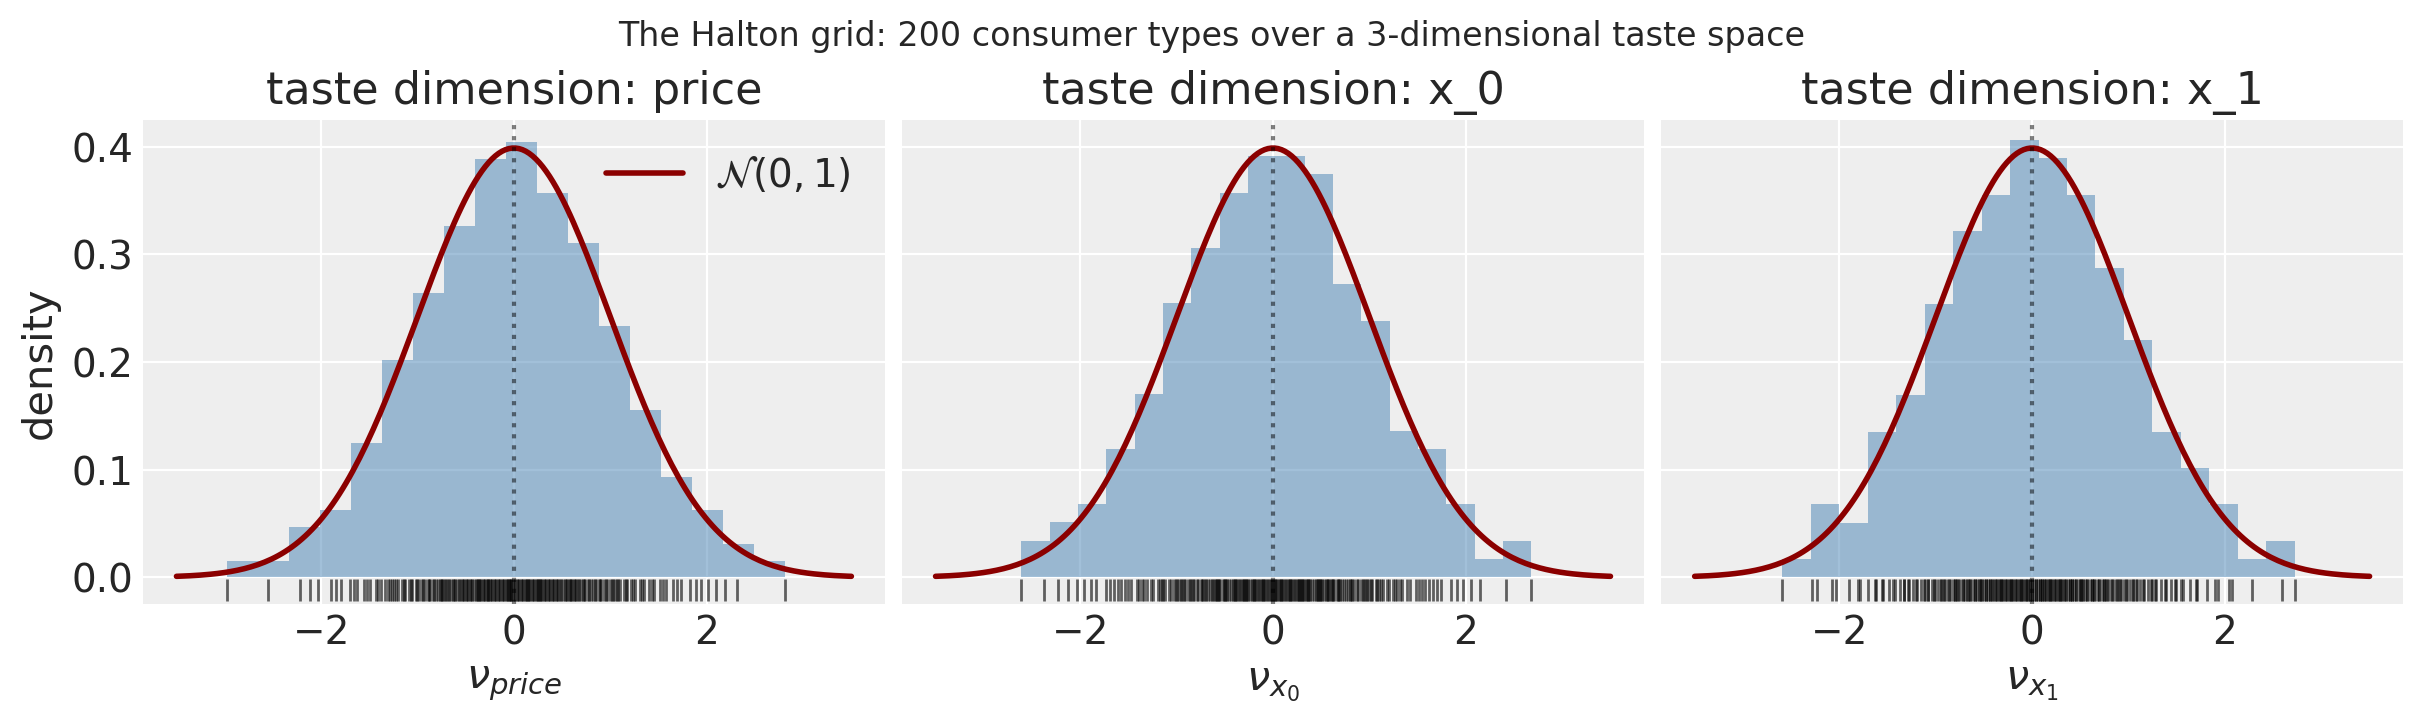

In [8]:
print(f"model._halton shape: {model._halton.shape}")
print(
    f"  {model._halton.shape[0]} consumer types, "
    f"{model._halton.shape[1]} random-coefficient dimensions"
)
print(f"\n_random_coef_names: {model._random_coef_names}")
print("\nFirst 6 consumer types (one row per type, columns are taste dimensions):")
print(np.round(model._halton[:6], 3))

# One histogram panel per random-coefficient dimension.
fig, axes = plt.subplots(
    1,
    model._halton.shape[1],
    layout="constrained",
    figsize=(4 * model._halton.shape[1], 3.5),
    sharey=True,
)
x_grid = np.linspace(-3.5, 3.5, 200)
for d, ax in enumerate(axes):
    draws = model._halton[:, d]
    ax.hist(draws, bins=18, density=True, alpha=0.5, color="steelblue")
    ax.plot(
        x_grid, norm.pdf(x_grid), color="darkred", lw=2, label=r"$\mathcal{N}(0,1)$"
    )
    ax.plot(
        draws, np.full_like(draws, -0.012), "|", color="black", markersize=8, alpha=0.6
    )
    ax.axvline(0, color="black", linestyle=":", alpha=0.5)
    ax.set_xlabel(rf"$\nu_{{{model._random_coef_names[d]}}}$")
    ax.set_ylim(bottom=-0.025)
    if d == 0:
        ax.set_ylabel("density")
        ax.legend()
    ax.set_title(f"taste dimension: {model._random_coef_names[d]}")
fig.suptitle("The Halton grid: 200 consumer types over a 3-dimensional taste space")
plt.show()

Sampling: [alpha, beta, gamma_xi_eta, log_share_ratio, omega_xi, pi_0, pi_z, price_obs, sigma_eta, sigma_random, sigma_xi_j, xi_j_raw, xi_tilde_raw]


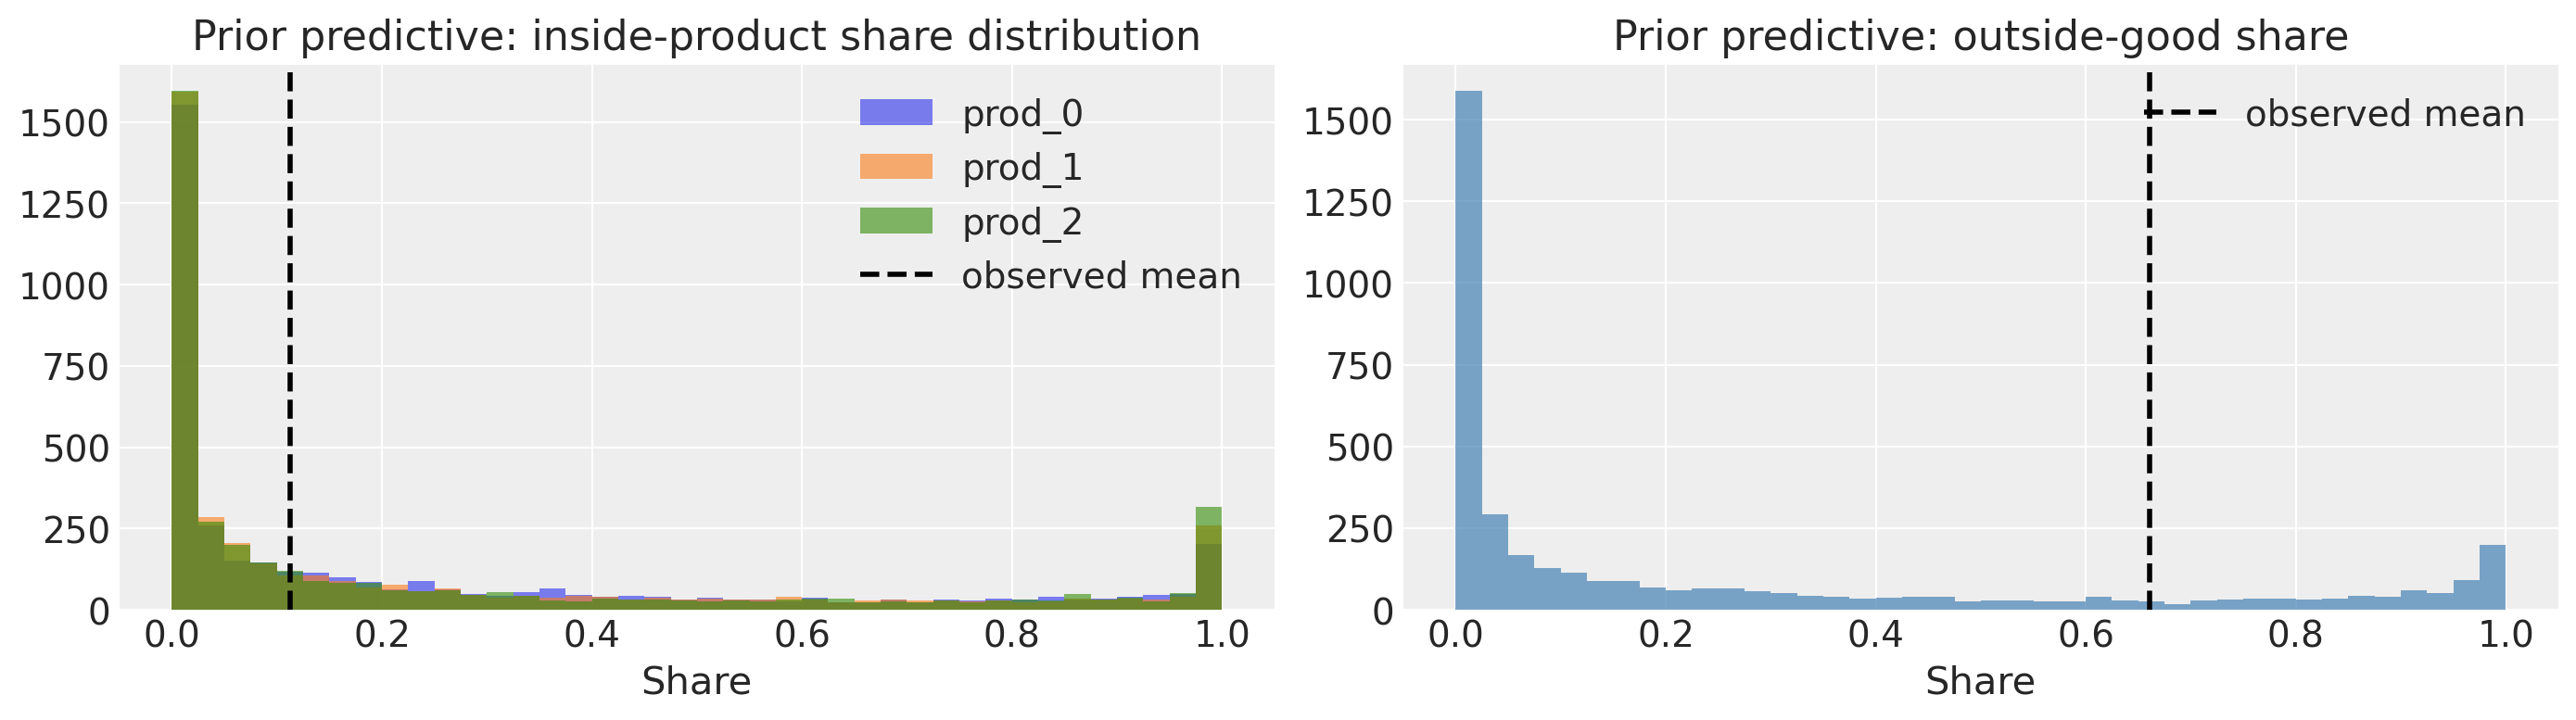

Shares sum to 1: True


In [9]:
prior = model.sample_prior_predictive(samples=100)

fig, axs = plt.subplots(1, 2, figsize=(14, 4))

# Inside shares
s_in_prior = prior.prior["s_inside"].values.reshape(-1, model._M, model._J)
for j, pname in enumerate(model._inside_products):
    axs[0].hist(s_in_prior[:, :, j].ravel(), bins=40, alpha=0.6, label=pname)
axs[0].axvline(
    df[df["product"] != "outside"].groupby("product")["share"].mean().mean(),
    color="k",
    lw=2,
    ls="--",
    label="observed mean",
)
axs[0].set_title("Prior predictive: inside-product share distribution")
axs[0].set_xlabel("Share")
axs[0].legend()

# Outside share
s_out_prior = prior.prior["s_outside"].values.ravel()
axs[1].hist(s_out_prior, bins=40, color="steelblue", alpha=0.7)
axs[1].axvline(
    df[df["product"] == "outside"]["share"].mean(),
    color="k",
    lw=2,
    ls="--",
    label="observed mean",
)
axs[1].set_title("Prior predictive: outside-good share")
axs[1].set_xlabel("Share")
axs[1].legend()

plt.tight_layout()
plt.show()
print(
    f"Shares sum to 1: "
    f"{np.allclose(s_in_prior.sum(axis=-1) + prior.prior['s_outside'].values[0], 1.0)}"
)

## 3. Fitting the model with instruments

The model is fit with the `nutpie` backend. We use small draw counts here for speed. In practice use `draws=2000, tune=2000, chains=4`.


In [10]:
_FIT_KWARGS = dict(
    nuts_sampler="nutpie",
    draws=1000,
    tune=1000,
    chains=4,
    progressbar=True,
    random_seed=0,
)

model.fit(**_FIT_KWARGS)
n_div = int(model.idata.sample_stats["diverging"].values.sum())
print(f"Divergences: {n_div}")  # should be 0

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.09,127
,2000,0,0.08,63
,2000,0,0.08,63
,2000,0,0.08,127


Divergences: 0


## 4. Posterior summary and parameter recovery

We check whether the fitted posterior recovers the known DGP parameters. The key structural parameters are:

- `alpha_r`: the price coefficient; should be negative and close to the true value.
- `beta_r`: characteristic utility weights; should recover `true_beta`.
- `sigma_random`: a length-3 vector with one entry per random-coefficient dimension. Entries should recover `(sigma_alpha, sigma_beta[0], sigma_beta[1])` from the DGP.
- `rho_price_xi`: the endogeneity correlation; a posterior away from zero confirms that price is endogenous.


In [11]:
key_vars = ["alpha_r", "beta_r", "sigma_random", "rho_price_xi"]
az.summary(model.idata, var_names=key_vars, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_r[all],-1.99,0.07,-2.13,-1.86,0.00,0.00,473.98,983.80,1.00
"beta_r[all, x_0]",0.74,0.07,0.62,0.87,0.00,0.00,525.38,924.05,1.00
"beta_r[all, x_1]",1.19,0.04,1.11,1.25,0.00,0.00,826.33,1278.86,1.00
sigma_random[price],0.53,0.05,0.45,0.62,0.00,0.00,664.74,1240.15,1.00
sigma_random[x_0],0.49,0.25,0.00,0.86,0.01,0.01,515.65,611.93,1.00
sigma_random[x_1],0.47,0.09,0.30,0.63,0.00,0.00,888.25,853.57,1.00
rho_price_xi,0.51,0.11,0.28,0.71,0.00,0.00,795.60,1154.85,1.01


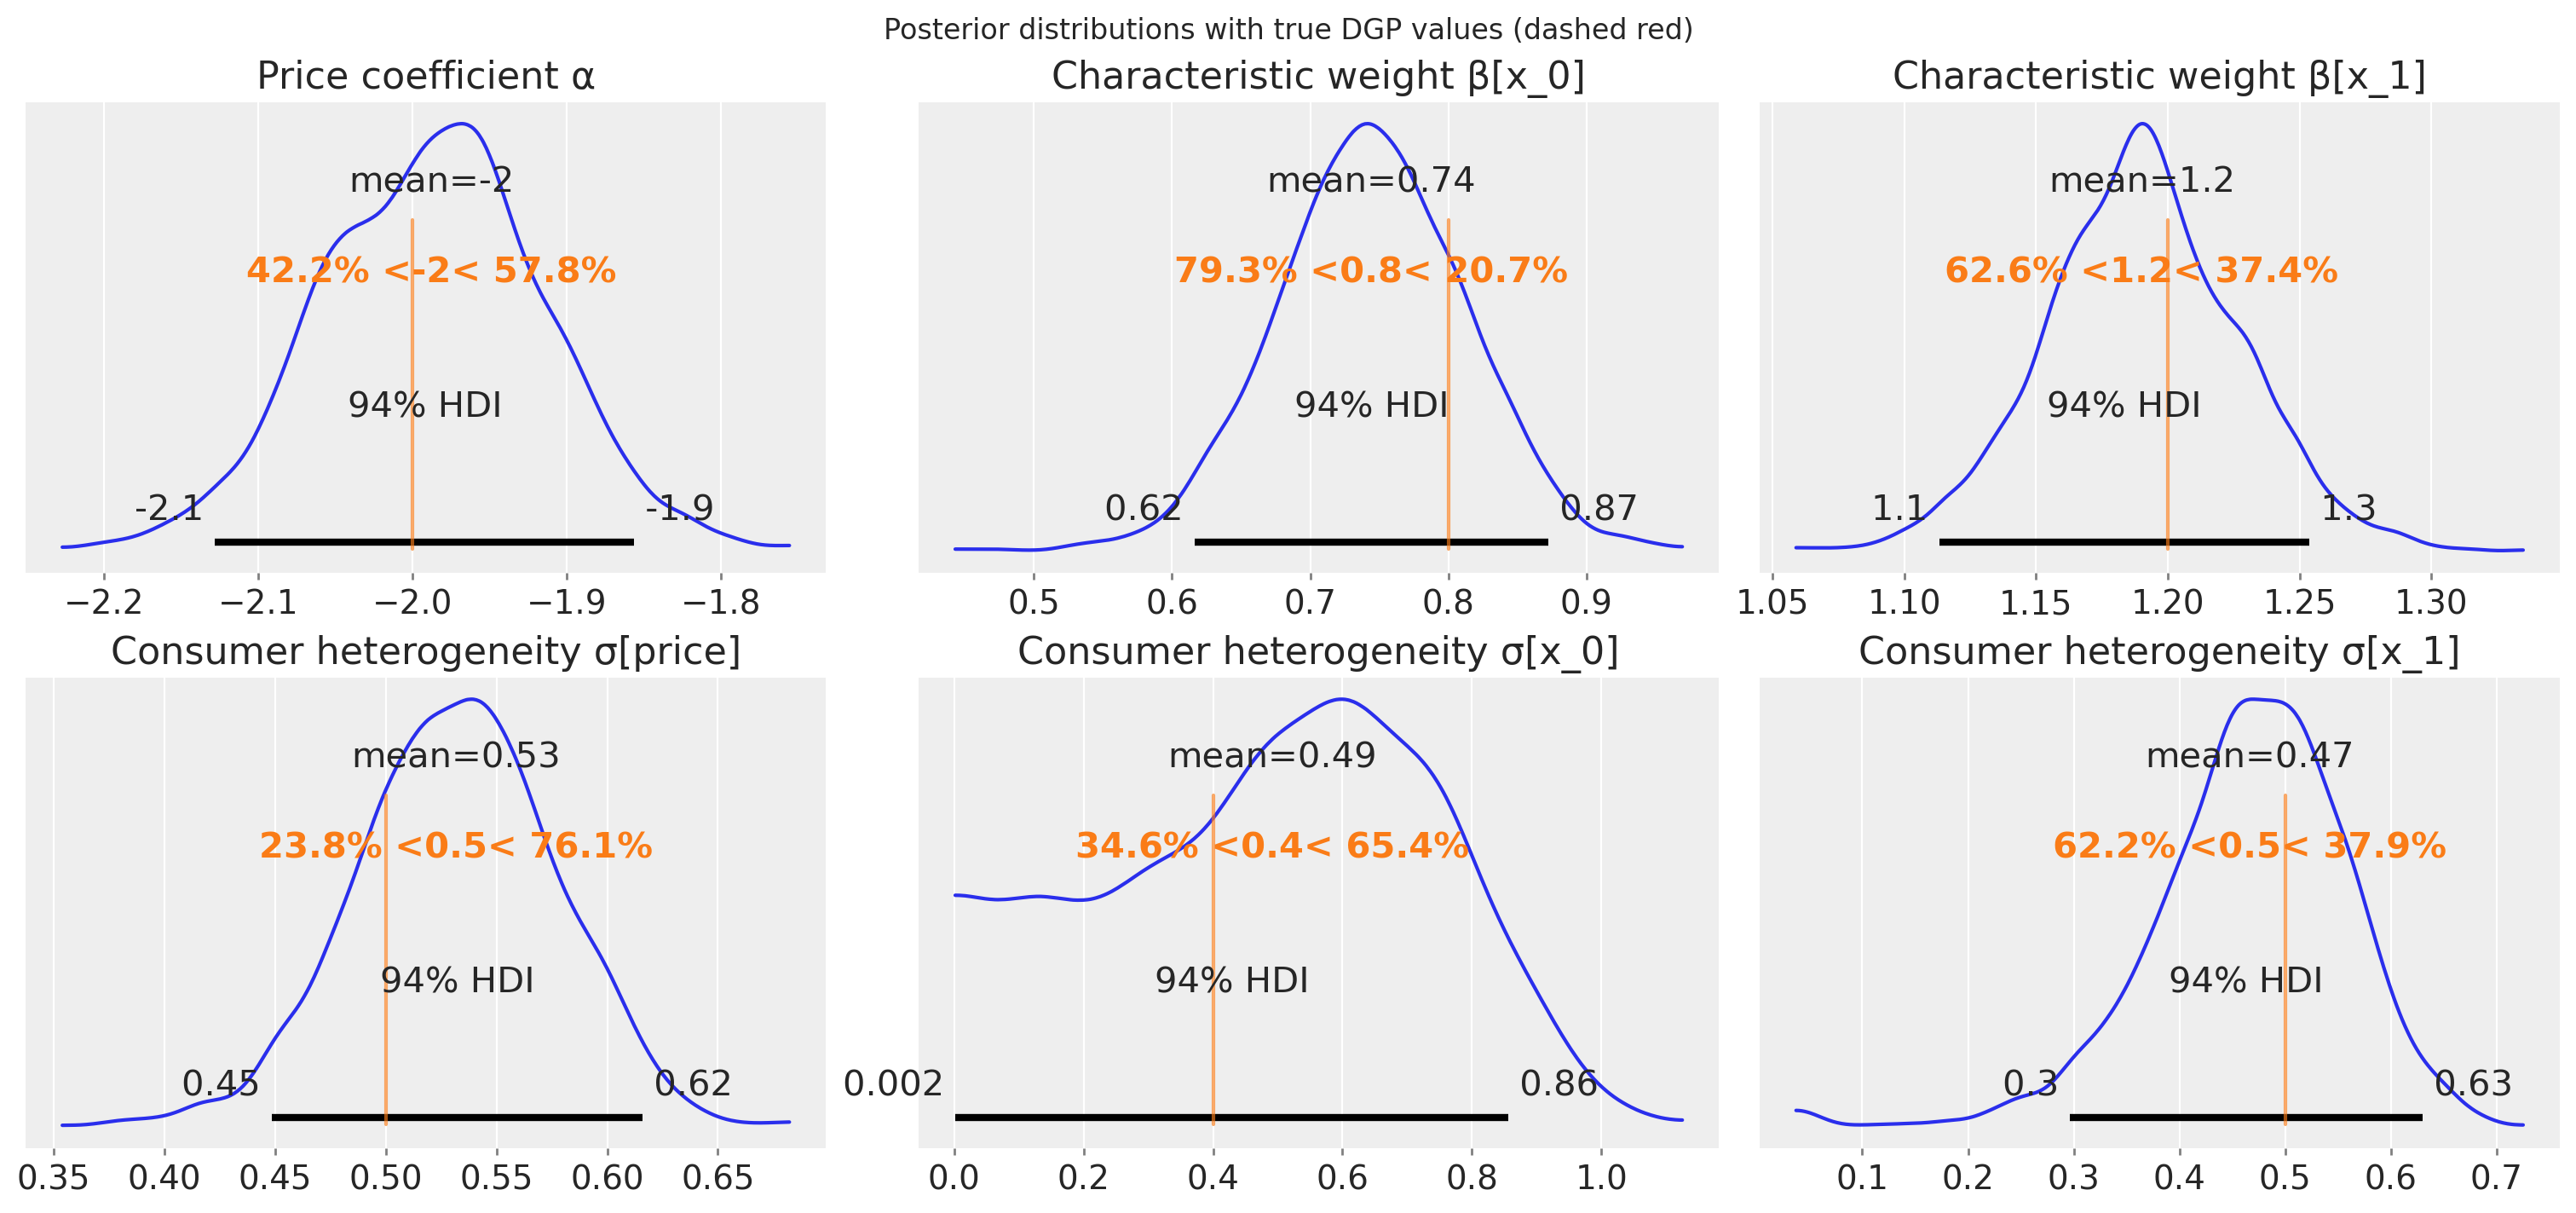

In [12]:
fig, axs = plt.subplots(2, 3, layout="constrained", figsize=(15, 7))

# Top row: alpha, beta[0], beta[1]
az.plot_posterior(
    model.idata, var_names=["alpha_r"], ref_val=truth["alpha"], ax=axs[0, 0]
)
axs[0, 0].set_title("Price coefficient α")

for k, ax in zip(range(2), axs[0, 1:], strict=True):
    az.plot_posterior(
        model.idata,
        var_names=["beta_r"],
        coords={"characteristic": truth["characteristic_cols"][k]},
        ref_val=float(truth["beta"][k]),
        ax=ax,
    )
    ax.set_title(f"Characteristic weight β[{truth['characteristic_cols'][k]}]")

# Bottom row: sigma_random[price], sigma_random[x_0], sigma_random[x_1]
sigma_truths = [
    ("price", truth["sigma_alpha"]),
    (truth["characteristic_cols"][0], truth["sigma_beta"][0]),
    (truth["characteristic_cols"][1], truth["sigma_beta"][1]),
]
for (rc_name, ref_val), ax in zip(sigma_truths, axs[1], strict=True):
    az.plot_posterior(
        model.idata,
        var_names=["sigma_random"],
        coords={"random_coef": rc_name},
        ref_val=float(ref_val),
        ax=ax,
    )
    ax.set_title(f"Consumer heterogeneity σ[{rc_name}]")

fig.suptitle("Posterior distributions with true DGP values (dashed red)")
plt.show()

## 5. Endogeneity correction: IV vs. no-IV

The headline feature of BLP is the endogeneity correction. When prices are set by firms that observe demand shocks $\xi_{jt}$, regressing shares on prices without instruments overstates willingness-to-pay (biases $\alpha$ toward zero). We fit a second model *without* instruments to illustrate the bias. With `price_xi_corr=0.6` in the DGP, the no-IV estimator should recover an $\alpha$ pulled toward zero.


In [13]:
# Fit without instruments (endogeneity bias expected)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model_noiv = BayesianBLP(
        market_data=df,
        characteristics=truth["characteristic_cols"],
        instruments=None,  # no IV
        random_coef_on=["price", "x_0", "x_1"],
        n_mc_draws=200,
        random_seed=0,
    )
    model_noiv.fit(**_FIT_KWARGS)

iv_alpha = float(model.idata.posterior["alpha_r"].values.mean())
noiv_alpha = float(model_noiv.idata.posterior["alpha_r"].values.mean())

print(f"True alpha:            {truth['alpha']:+.3f}")
print(
    f"IV posterior mean:     {iv_alpha:+.3f}  "
    f"(bias {abs(truth['alpha'] - iv_alpha):.3f})"
)
print(
    f"no-IV posterior mean:  {noiv_alpha:+.3f}  "
    f"(bias {abs(truth['alpha'] - noiv_alpha):.3f})"
)
print()
if abs(truth["alpha"] - noiv_alpha) > abs(truth["alpha"] - iv_alpha):
    print("✓  IV fit is closer to truth, endogeneity correction is working.")
else:
    print("✗  Unexpected — check the seed / DGP.")

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.09,127
,2000,0,0.08,31
,2000,0,0.08,63
,2000,0,0.08,255


True alpha:            -2.000
IV posterior mean:     -1.988  (bias 0.012)
no-IV posterior mean:  -1.907  (bias 0.093)

✓  IV fit is closer to truth, endogeneity correction is working.


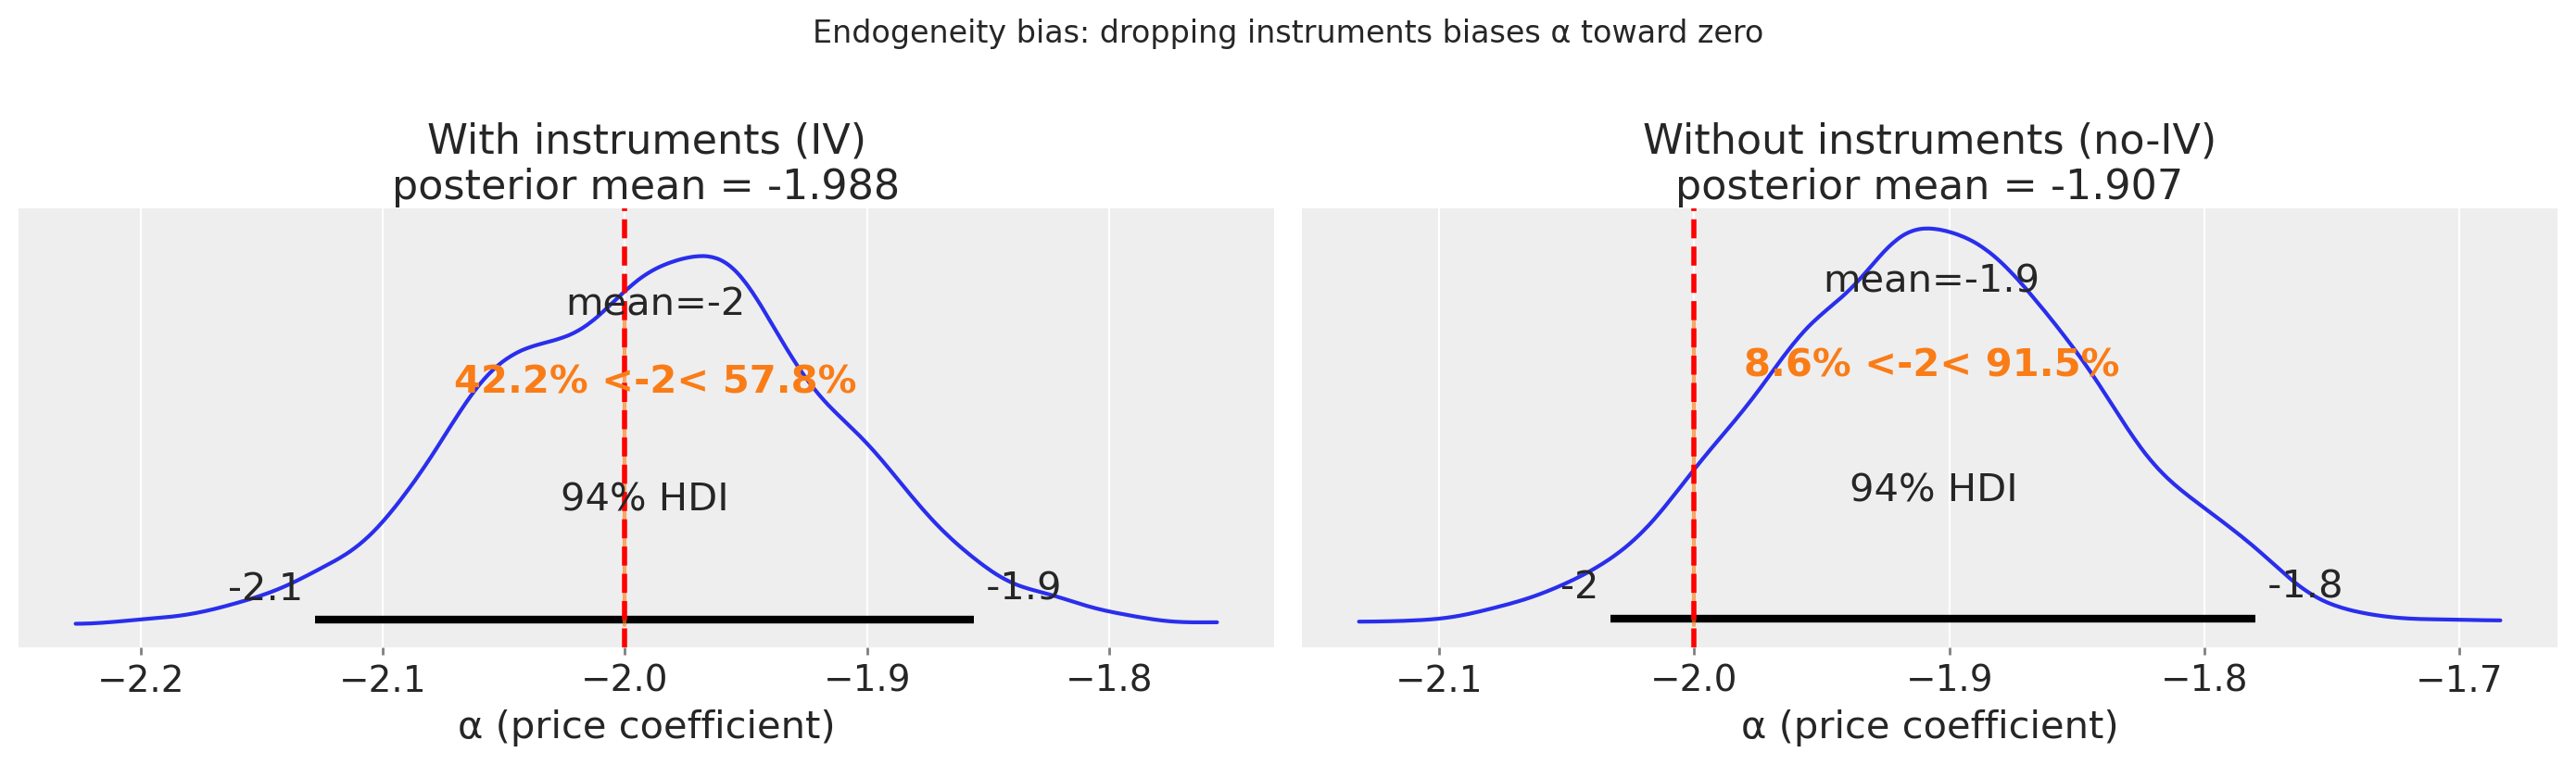

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

az.plot_posterior(
    model.idata,
    var_names=["alpha_r"],
    ref_val=truth["alpha"],
    ax=axs[0],
)
axs[0].set_title(f"With instruments (IV)\nposterior mean = {iv_alpha:.3f}")

az.plot_posterior(
    model_noiv.idata,
    var_names=["alpha_r"],
    ref_val=truth["alpha"],
    ax=axs[1],
)
axs[1].set_title(f"Without instruments (no-IV)\nposterior mean = {noiv_alpha:.3f}")

for ax in axs:
    ax.axvline(truth["alpha"], color="red", lw=2, ls="--", label="truth")
    ax.set_xlabel("α (price coefficient)")

plt.suptitle("Endogeneity bias: dropping instruments biases α toward zero", y=1.02)
plt.tight_layout()
plt.show()

## 6. Price elasticities

The closed-form mixed-logit elasticity is

$$
\varepsilon_{jk}(m) = \frac{p_{km}}{s_{jm}} \cdot \frac{1}{R}
\sum_r \alpha_{ir}(m) \cdot s_{jmr} \bigl(\delta_{jk} - s_{kmr}\bigr)
$$

where the integral over consumer types reuses the same Halton draws as the likelihood (essentially free). Own-price elasticities sit on the diagonal (negative); cross-price elasticities sit off-diagonal (positive for substitutes). `elasticities(at='mean')` returns the posterior-mean elasticity matrix; `at='samples'` returns the full posterior distribution.


In [15]:
elast = model.elasticities(at="mean", n_samples=300)
print("Elasticity array shape:", elast.shape)  # (market, share, price)
print("Dims:", elast.dims)

Elasticity array shape: (40, 3, 3)
Dims: ('market', 'share', 'price')


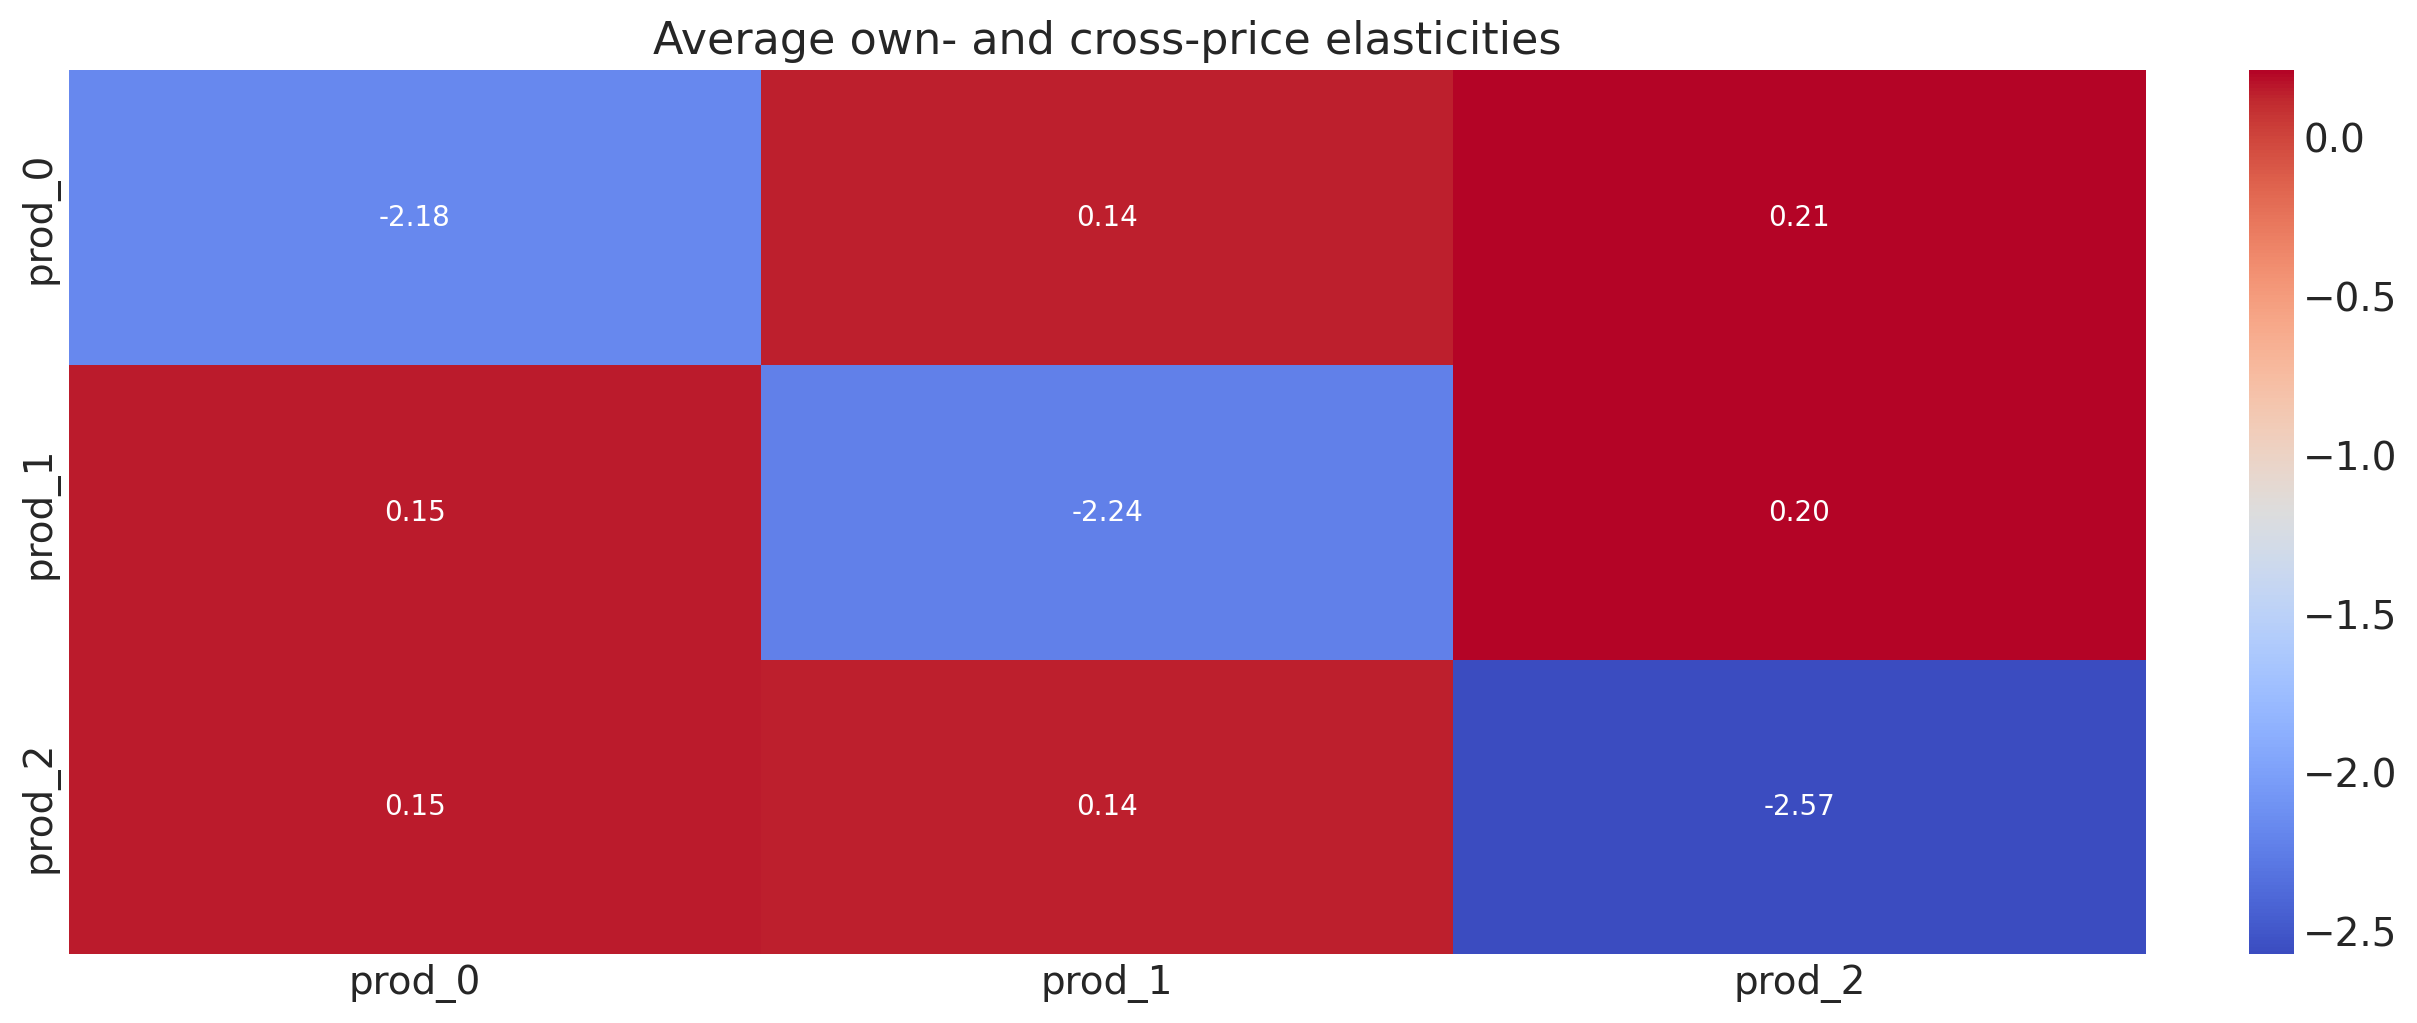

In [16]:
# Average across markets
elast_mean = elast.mean(dim="market").values  # (J, J)

sns.heatmap(
    elast_mean,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    xticklabels=model._inside_products,
    yticklabels=model._inside_products,
)
plt.title("Average own- and cross-price elasticities");

### Posterior distribution of the market-averaged own elasticity

The heatmap above shows the posterior *mean* elasticity per cell. To see the **uncertainty** around each product's own-price elasticity, we average across markets *per posterior sample* and plot the resulting one-dimensional posterior:

$$
\bar{\varepsilon}_{jj}(s) = \frac{1}{M} \sum_m \varepsilon_{jj}(m, s)
$$

This produces one value per posterior sample per product: the *typical* own-price elasticity for that SKU across the panel. The result is a clean unimodal posterior whose width reflects joint uncertainty in $\alpha_r$, $\sigma_{\text{random}}$, and $\xi$. Averaging *per sample* preserves the posterior dependence structure; averaging *after* flattening sample × market would smear the genuine uncertainty across a market-by-market mixture.


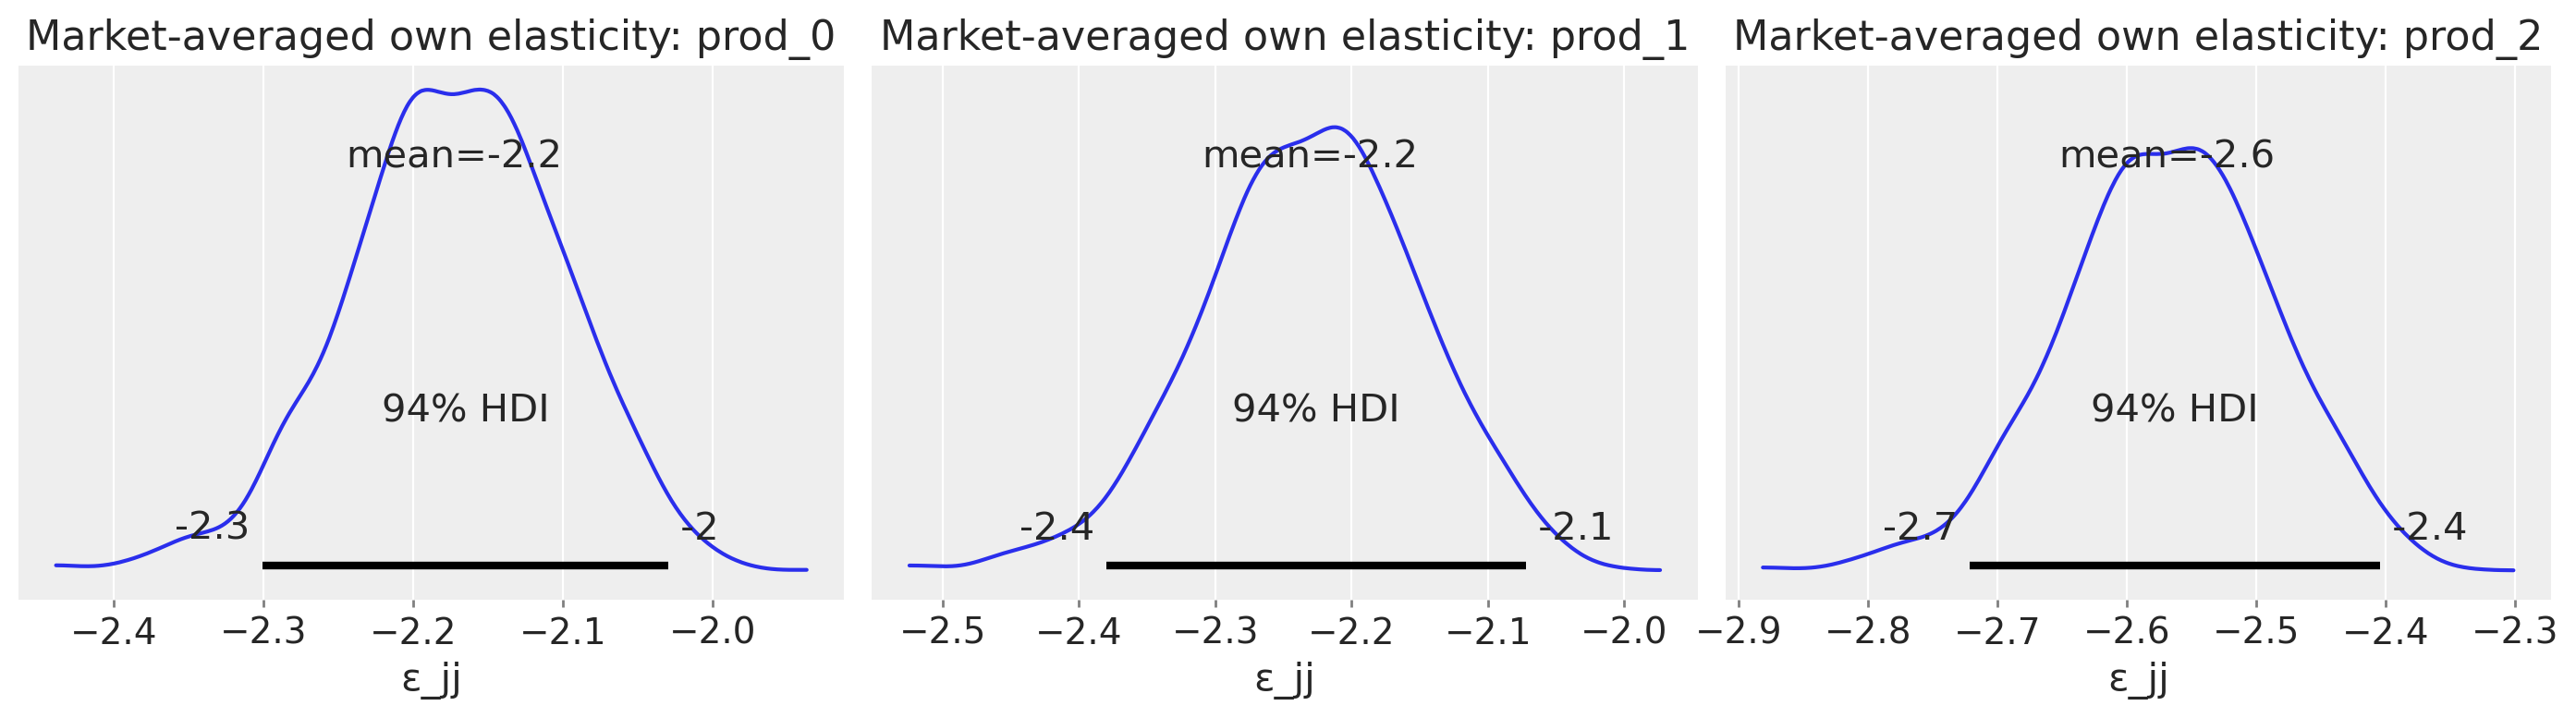

In [17]:
# Posterior distribution of own-price elasticity for the first product
elast = model.elasticities(at="mean", n_samples=2000)  # was 300
elast_samples = model.elasticities(at="samples", n_samples=2000)  # was 300

fig, axs = plt.subplots(1, model._J, figsize=(14, 4), sharey=True)
for j, (ax, pname) in enumerate(zip(axs, model._inside_products, strict=True)):
    # Average across markets per posterior sample → smooth 1D posterior
    own_avg = elast_samples.values[:, :, j, j].mean(axis=1)  # (sample,)
    az.plot_posterior({"own_ε": own_avg}, var_names=["own_ε"], ax=ax)
    ax.set_title(f"Market-averaged own elasticity: {pname}")
    ax.set_xlabel("ε_jj")
plt.tight_layout()

### Per-market variation in own-price elasticity

Averaging across markets hides genuine *cross-market* heterogeneity: the same product can be more elastic in markets where its baseline share is small or its realised price is high. The forest plot below shows the per-market 94 % HDI of `prod_0`'s own-price elasticity — one row per market — using the full posterior.

The horizontal spread of the interval *centres* is the structural across-market variation that the market-averaged plot collapsed; the *width* of each interval is per-market posterior uncertainty (typically wider in markets with sparse shares or extreme prices).


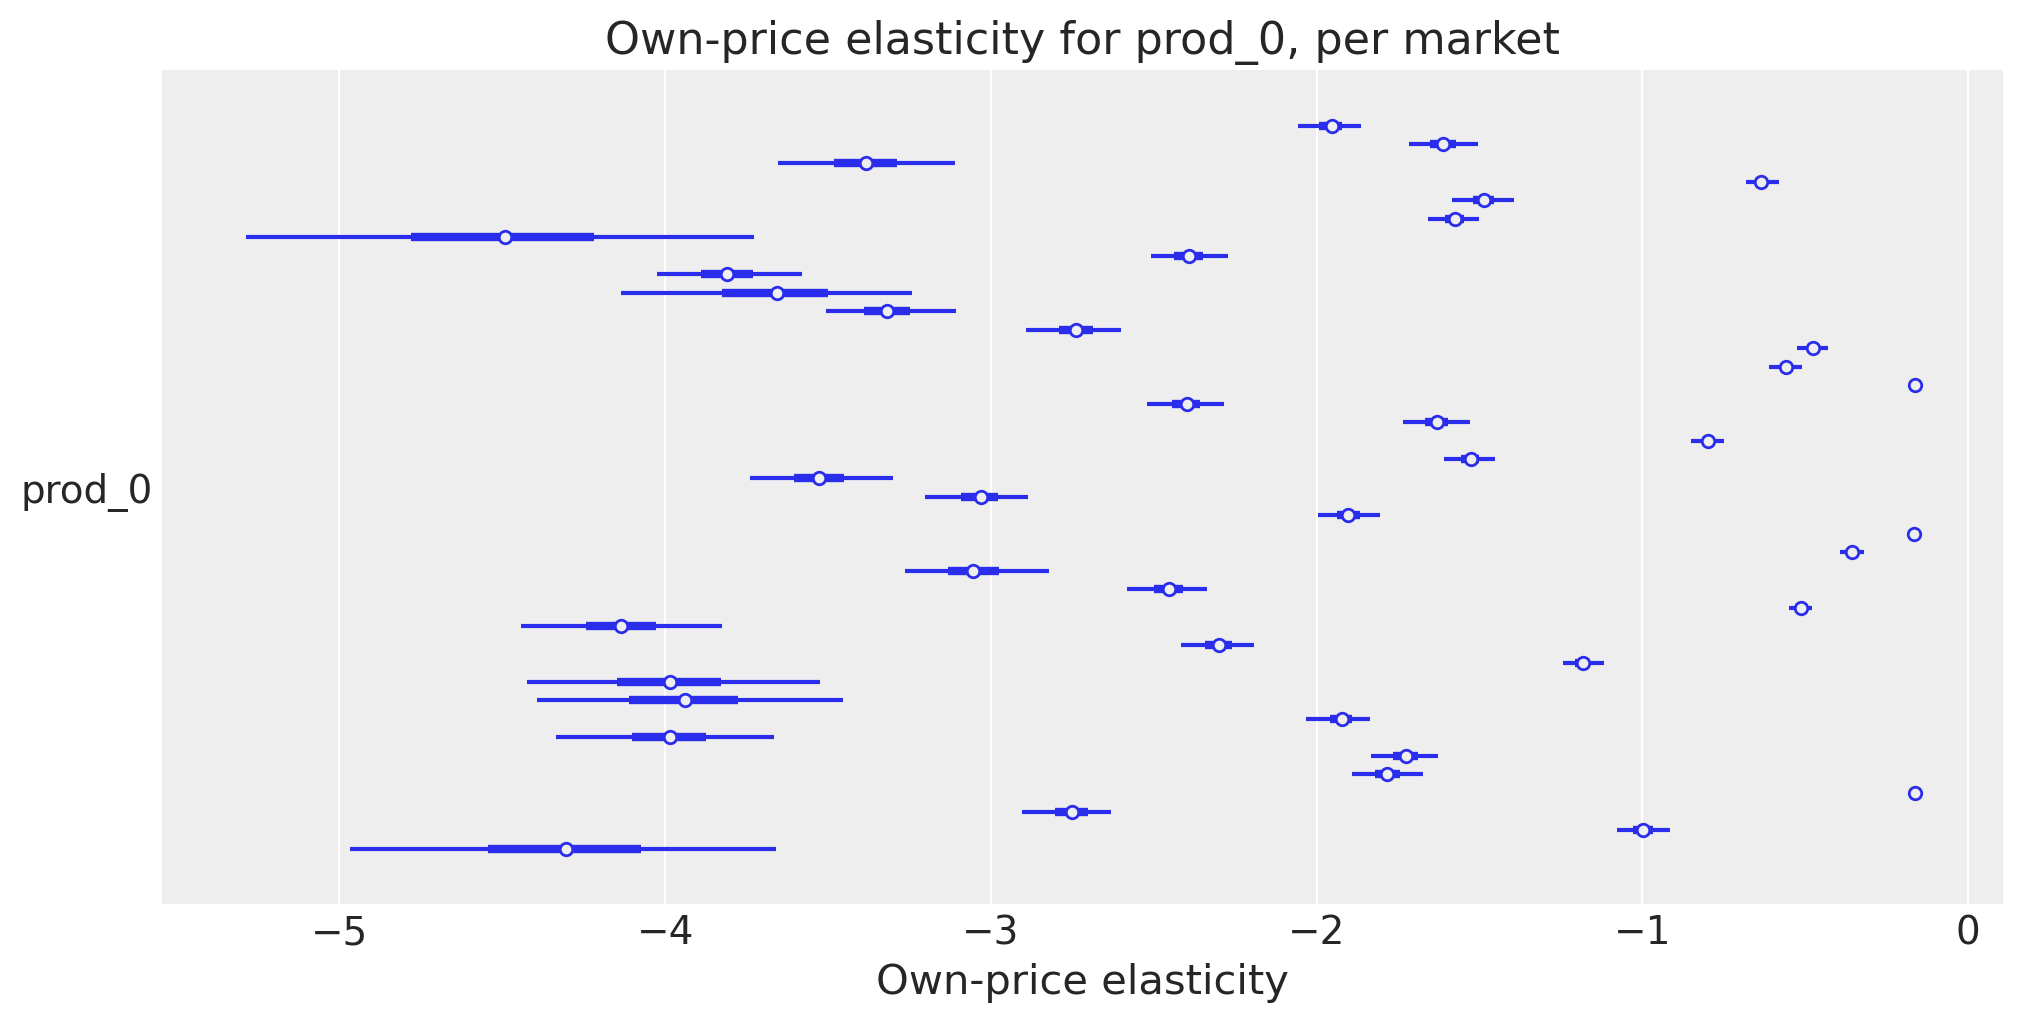

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
own = elast_samples.values[:, :, 0, 0]  # (sample, market) for prod_0
az.plot_forest(
    {"prod_0": own.T},  # (market, sample)
    combined=False,
    ax=ax,
)
ax.set_xlabel("Own-price elasticity")
ax.set_title("Own-price elasticity for prod_0, per market");

## 7. Counterfactual pricing

`counterfactual_shares(price_change=...)` holds the latent demand shock ξ_jt constant (read directly from the posterior) and re-evaluates the share equation at new prices. This is the structurally correct counterfactual: it asks *given the same unobserved market conditions*, what would market shares be at the new prices?

We examine a **10 % price hike on the first product**:
- its own share should fall (consumers substitute away)
- rival shares and the outside good should rise


In [19]:
target_product = model._inside_products[0]
print(f"Applying 10% price hike to: {target_product}")

baseline_cf = model.counterfactual_shares(price_change=None, n_samples=300)
shocked_cf = model.counterfactual_shares(
    price_change={target_product: 0.10}, n_samples=300
)

baseline_s = baseline_cf["s_inside"].mean(dim="sample").values  # (M, J)
shocked_s = shocked_cf["s_inside"].mean(dim="sample").values
delta_s = shocked_s - baseline_s  # share change

baseline_s_out = baseline_cf["s_outside"].mean(dim="sample").values  # (M,)
shocked_s_out = shocked_cf["s_outside"].mean(dim="sample").values

print("\nMarket-average share changes after 10% price hike on", target_product)
print("-" * 55)
for j, pname in enumerate(model._inside_products):
    b = baseline_s[:, j].mean()
    s = shocked_s[:, j].mean()
    print(f"  {pname:<12}  baseline={b:.4f}  shocked={s:.4f}  Δ={s - b:+.4f}")
print(
    f"  {'outside':<12}  baseline={baseline_s_out.mean():.4f}  "
    f"shocked={shocked_s_out.mean():.4f}  "
    f"Δ={shocked_s_out.mean() - baseline_s_out.mean():+.4f}"
)

Applying 10% price hike to: prod_0



Market-average share changes after 10% price hike on prod_0
-------------------------------------------------------
  prod_0        baseline=0.1111  shocked=0.1006  Δ=-0.0105
  prod_1        baseline=0.1412  shocked=0.1425  Δ=+0.0013
  prod_2        baseline=0.0873  shocked=0.0884  Δ=+0.0011
  outside       baseline=0.6604  shocked=0.6685  Δ=+0.0081


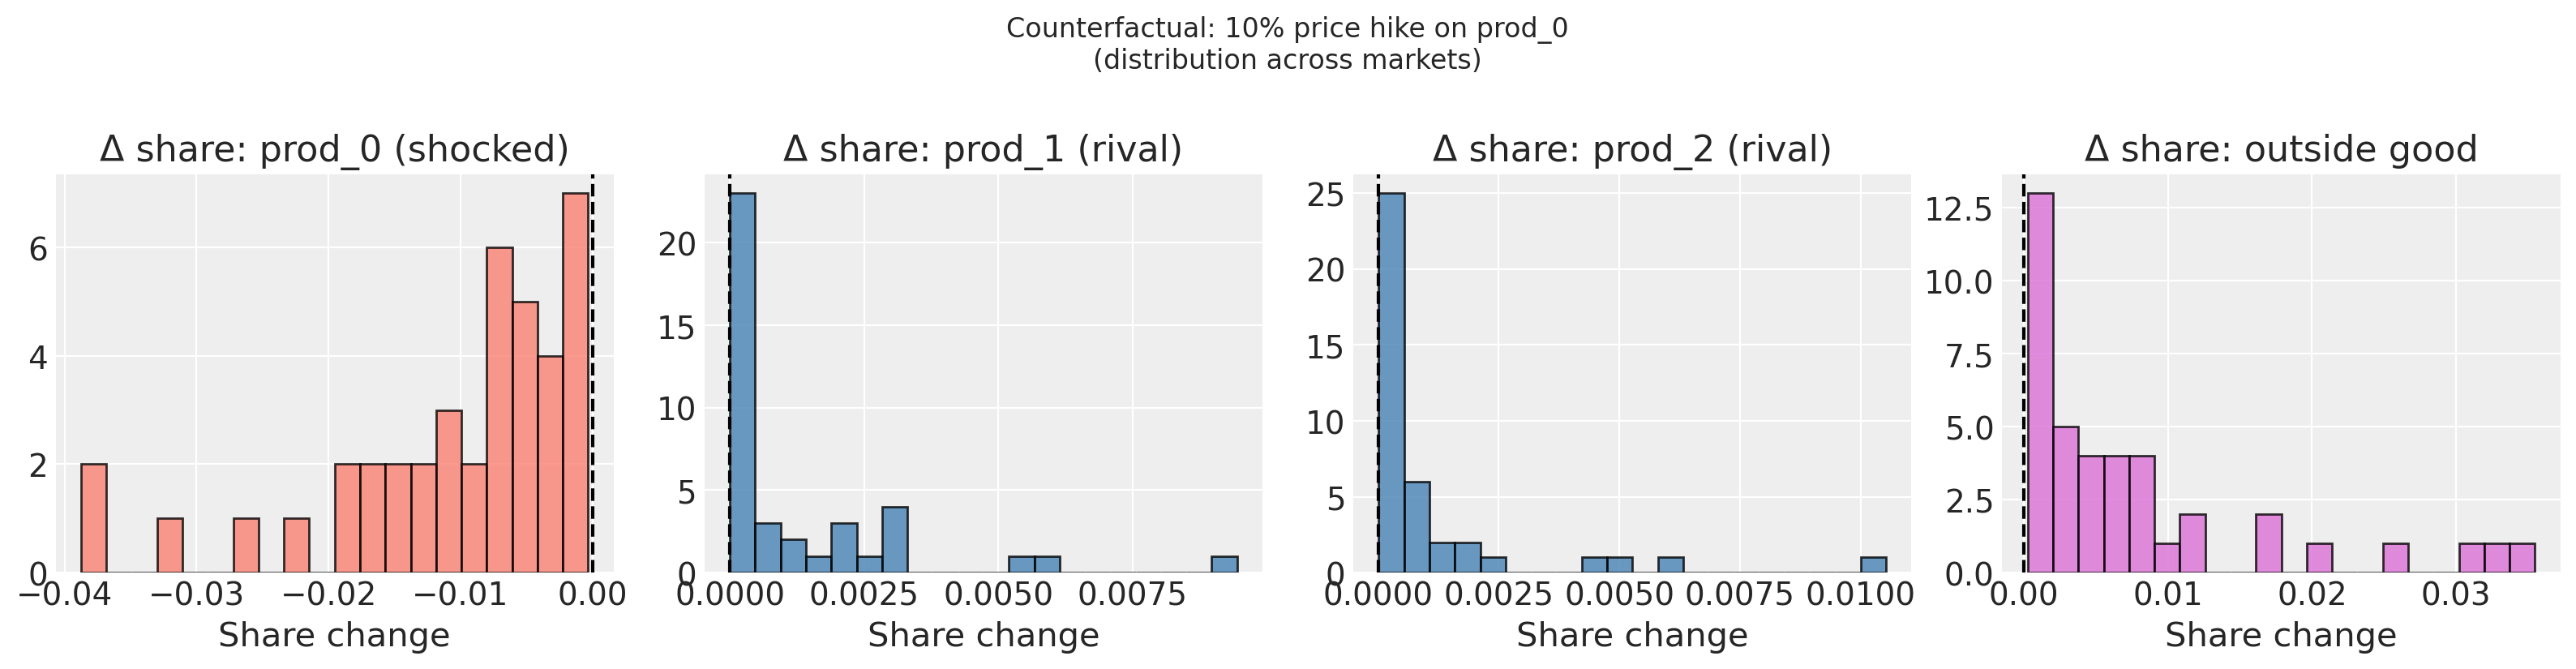

In [20]:
# Visualise share-change distributions across markets
fig, axs = plt.subplots(1, model._J + 1, figsize=(16, 4))

for j, (ax, pname) in enumerate(zip(axs[:-1], model._inside_products, strict=True)):
    colour = "salmon" if pname == target_product else "steelblue"
    ax.hist(delta_s[:, j], bins=20, color=colour, alpha=0.8, edgecolor="k")
    ax.axvline(0, color="k", lw=1.5, ls="--")
    ax.set_title(
        f"Δ share: {pname}" + (" (shocked)" if pname == target_product else " (rival)")
    )
    ax.set_xlabel("Share change")

delta_out = shocked_s_out - baseline_s_out
axs[-1].hist(delta_out, bins=20, color="orchid", alpha=0.8, edgecolor="k")
axs[-1].axvline(0, color="k", lw=1.5, ls="--")
axs[-1].set_title("Δ share: outside good")
axs[-1].set_xlabel("Share change")

plt.suptitle(
    f"Counterfactual: 10% price hike on {target_product}\n"
    "(distribution across markets)",
    y=1.02,
)
plt.tight_layout()
plt.show()

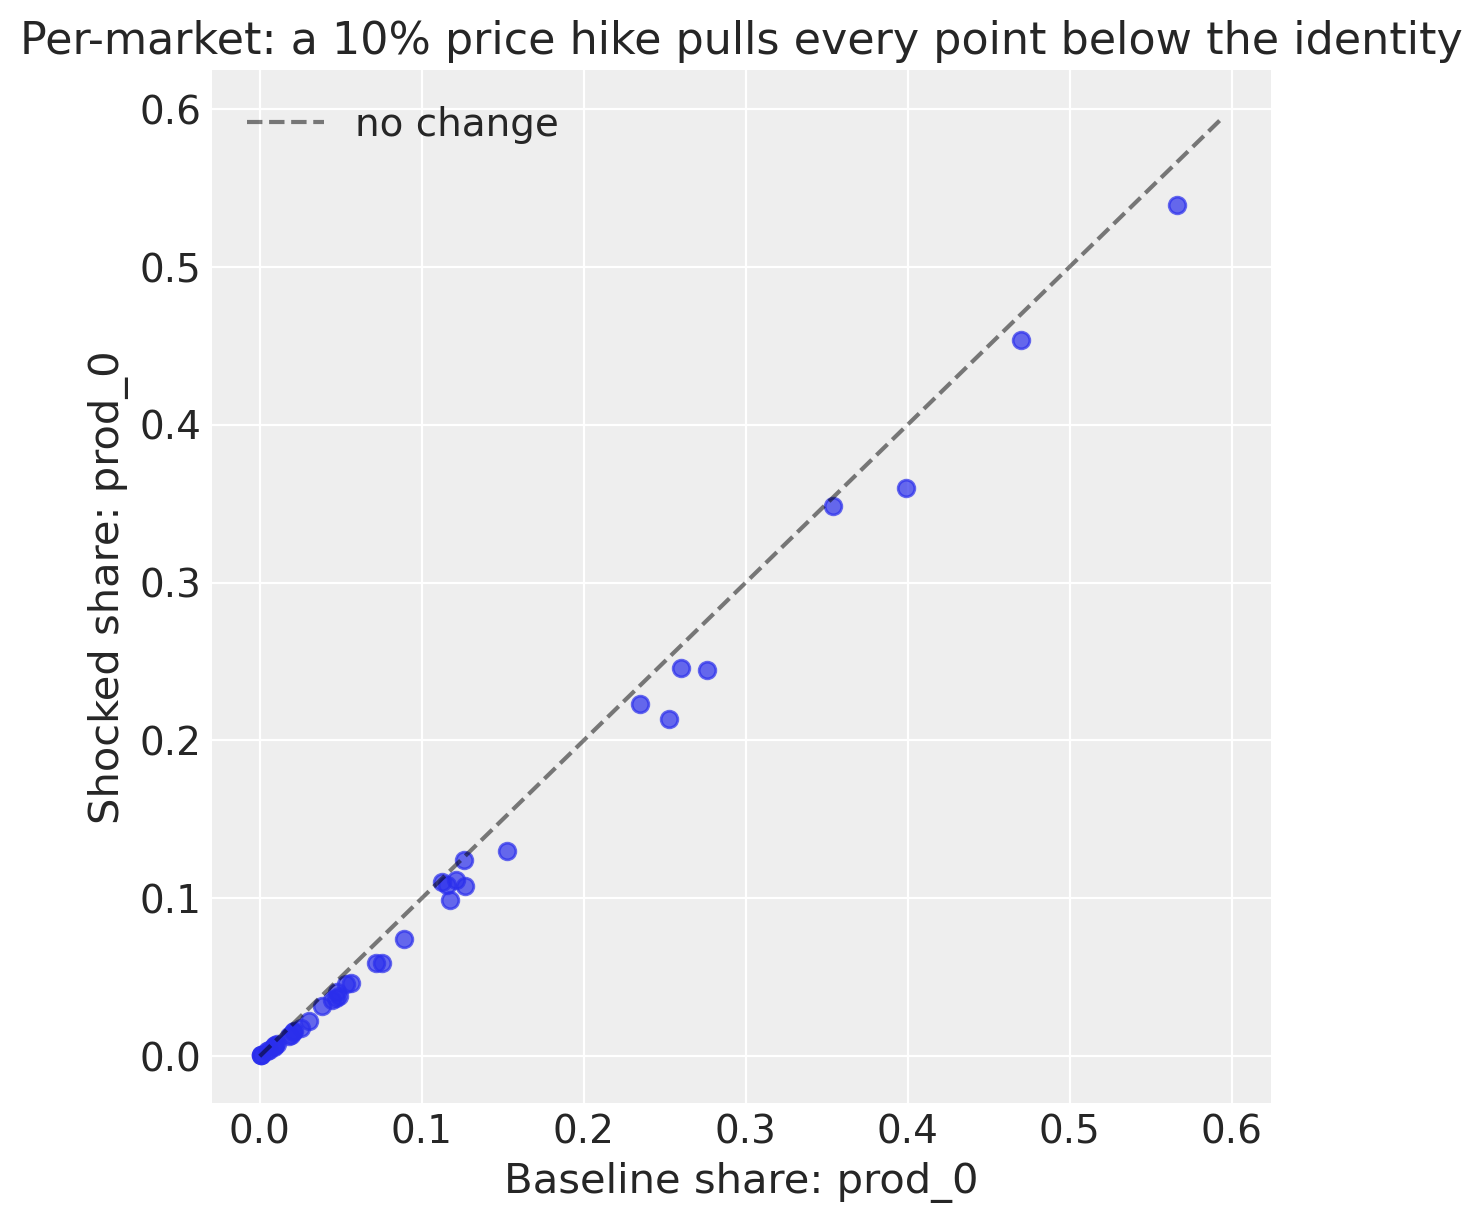

In [21]:
own_idx = model._inside_products.index(target_product)

fig, ax = plt.subplots(figsize=(6, 6))
b = baseline_cf["s_inside"].mean(dim="sample").values[:, own_idx]
s = shocked_cf["s_inside"].mean(dim="sample").values[:, own_idx]
ax.scatter(b, s, alpha=0.7)
lim = max(b.max(), s.max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", alpha=0.5, label="no change")
ax.set_xlabel(f"Baseline share: {target_product}")
ax.set_ylabel(f"Shocked share: {target_product}")
ax.set_title("Per-market: a 10% price hike pulls every point below the identity")
ax.legend()

Text(0.5, 1.0, 'Per-market Δshare from 10% price hike on prod_0')

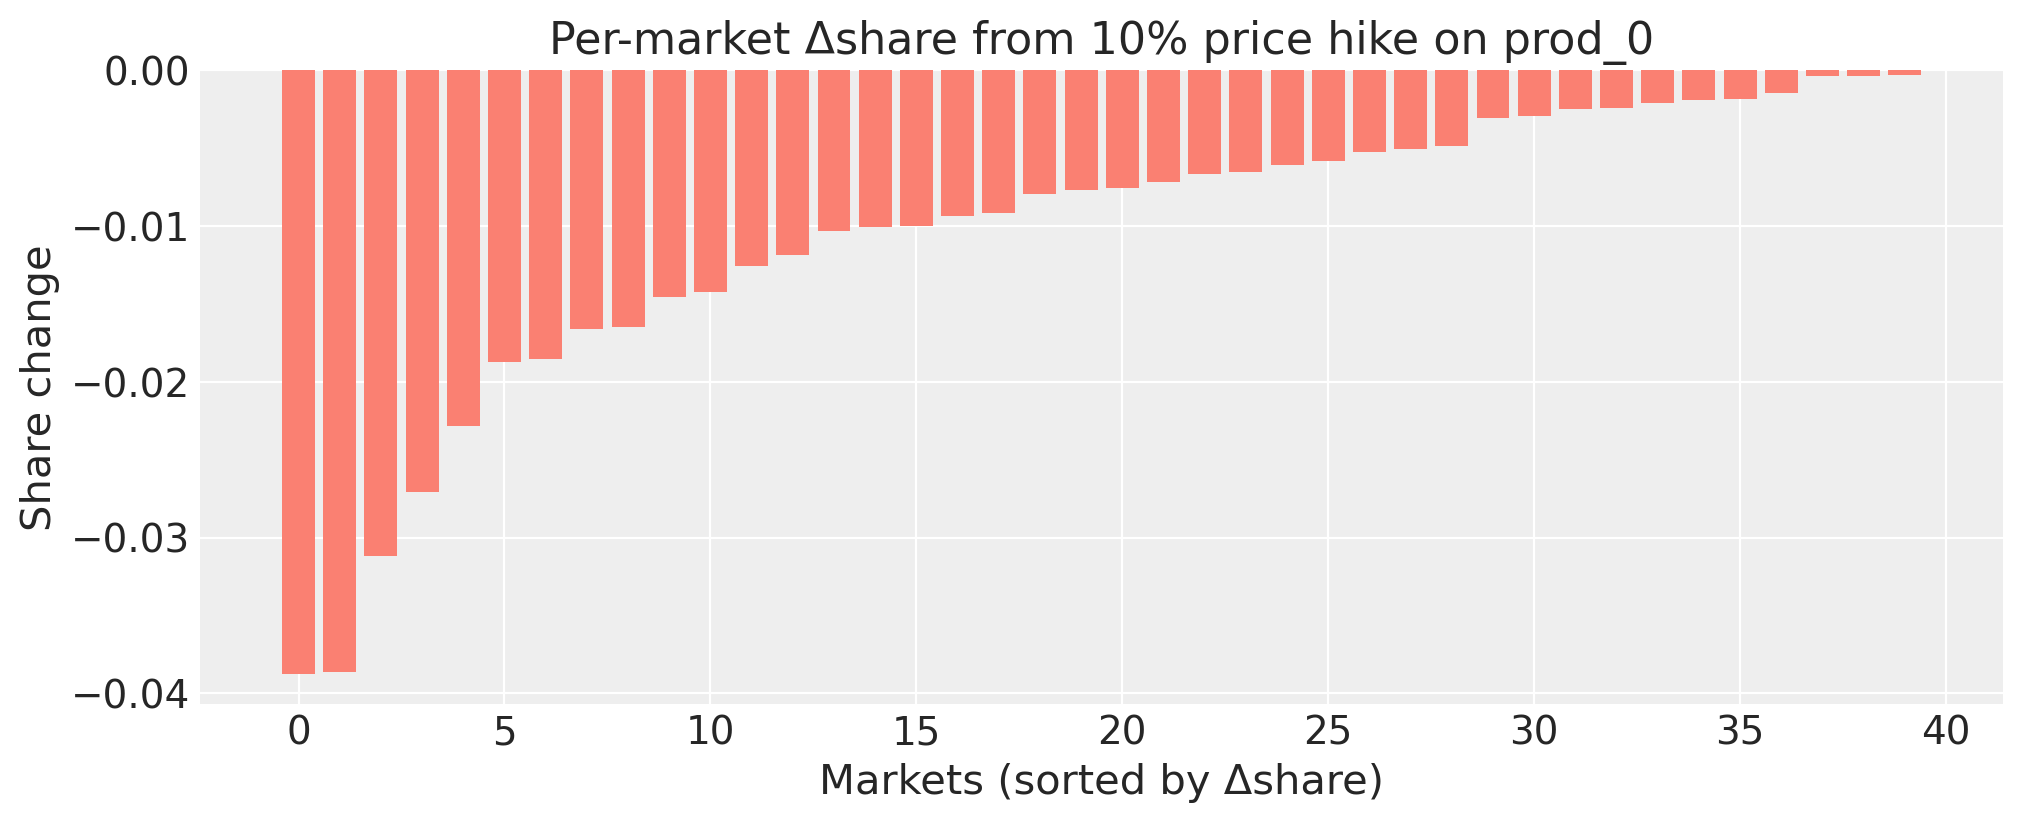

In [22]:
delta = (
    (shocked_cf["s_inside"] - baseline_cf["s_inside"])
    .mean(dim="sample")
    .values[:, own_idx]
)
order = np.argsort(delta)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(delta)), delta[order], color="salmon")
ax.set_xlabel("Markets (sorted by Δshare)")
ax.set_ylabel("Share change")
ax.set_title(f"Per-market Δshare from 10% price hike on {target_product}")

### Time-targeted counterfactuals

Because we constructed the model with `time_col="period"`, the counterfactual API accepts `periods=` and `regions=` coord-label arguments. Use them to scope an intervention to a specific time window or geography.

The cell below applies the same 10% price hike on `prod_0` *only* in periods 10–20. Outside that window the counterfactual shares match the baseline bit-for-bit; inside the window they match the full-panel counterfactual.


Outside the window: max |Δ vs baseline| = 0.0
Inside the window:  max |Δ vs full-panel cf| = 0.02820088126548989


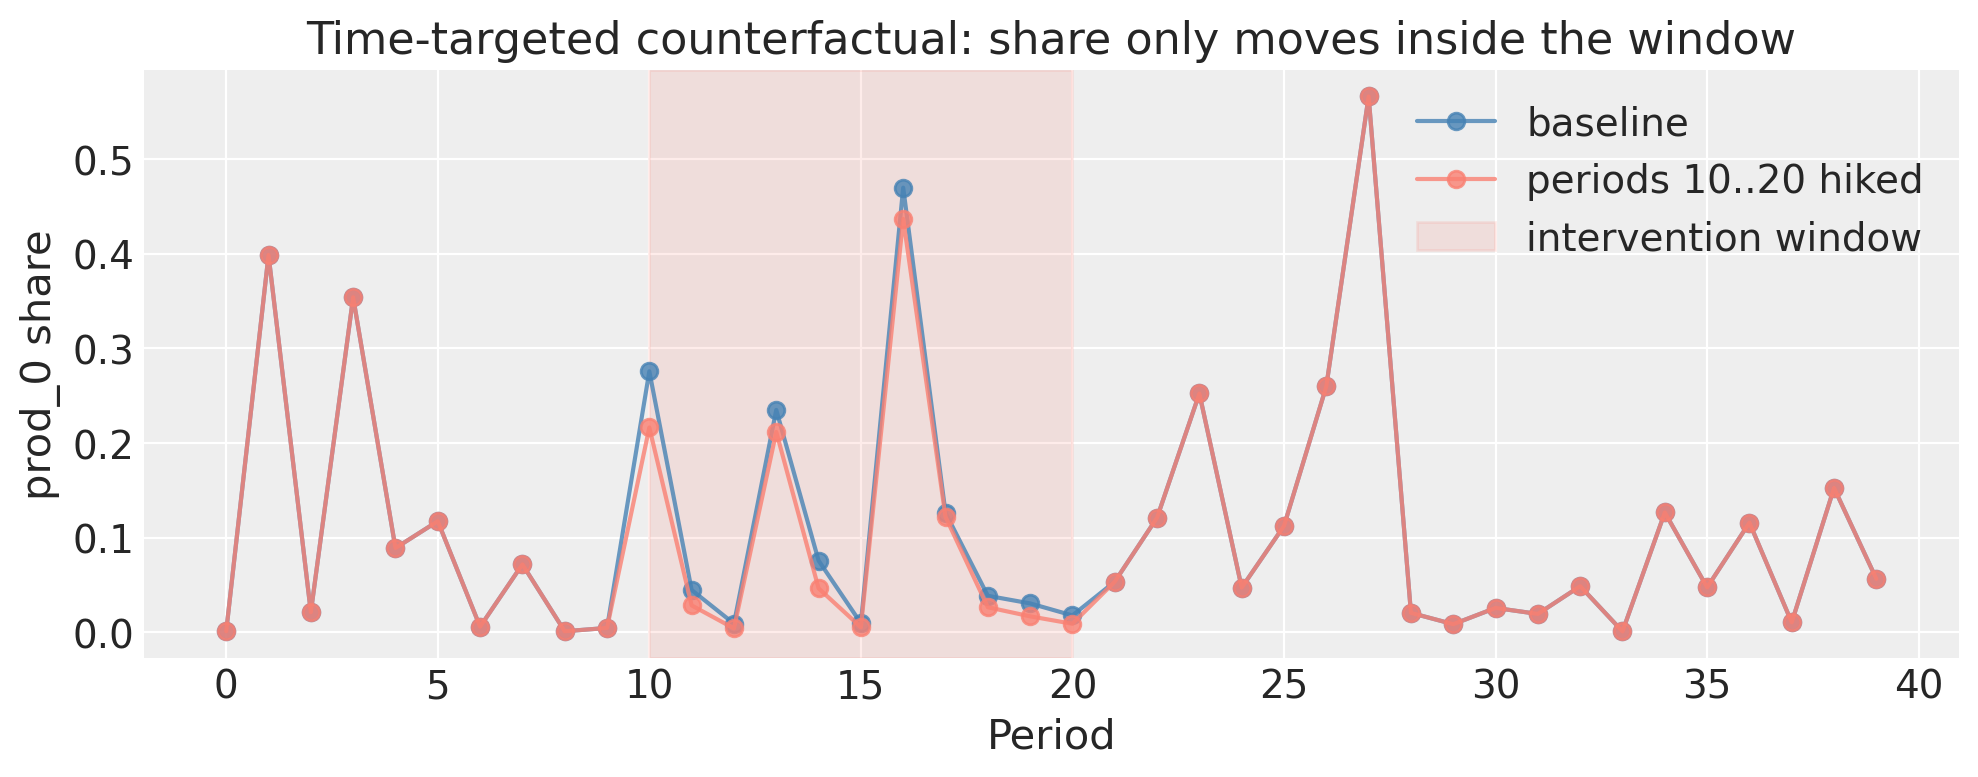

In [23]:
# Apply the 10% hike only in periods 10..20 (inclusive)
window = list(range(10, 21))
cf_window = model.counterfactual_shares(
    price_change={target_product: 0.20},
    periods=window,
    n_samples=300,
)

# The returned dataset carries period+region as non-dim coords on `market`,
# so we can verify the masking directly with xarray.
period_coord = cf_window.coords["period"].values
in_window = np.isin(period_coord, window)

baseline_inside = baseline_cf["s_inside"].mean(dim="sample").values[:, own_idx]
shocked_window_inside = cf_window["s_inside"].mean(dim="sample").values[:, own_idx]
shocked_full_inside = shocked_cf["s_inside"].mean(dim="sample").values[:, own_idx]

print(
    "Outside the window: max |Δ vs baseline| =",
    np.abs(shocked_window_inside[~in_window] - baseline_inside[~in_window]).max(),
)
print(
    "Inside the window:  max |Δ vs full-panel cf| =",
    np.abs(shocked_window_inside[in_window] - shocked_full_inside[in_window]).max(),
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    period_coord, baseline_inside, "o-", color="steelblue", label="baseline", alpha=0.8
)
ax.plot(
    period_coord,
    shocked_window_inside,
    "o-",
    color="salmon",
    label="periods 10..20 hiked",
    alpha=0.8,
)
ax.axvspan(10, 20, color="salmon", alpha=0.15, label="intervention window")
ax.set_xlabel("Period")
ax.set_ylabel(f"{target_product} share")
ax.set_title("Time-targeted counterfactual: share only moves inside the window")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Hierarchical pooling across regions

When markets belong to distinct geographic regions, `region_col` activates partial pooling across regions:

```
α_pop ~ N(0, 2)    τ_α ~ HalfNormal(1)
α_r   = α_pop + τ_α · α_r_raw        α_r_raw ~ N(0, 1)
```

This is the headline differentiator vs GMM BLP: thin markets are shrunk toward the population mean, which keeps inference stable while still using every data point.

We generate a 3-region panel with genuine region-level preference heterogeneity (`region_heterogeneity=0.6`) and check that $\tau_\alpha$ (the between-region SD) has posterior mass away from zero.


In [24]:
df_multi, truth_multi = generate_blp_panel(
    T=20,
    J=3,
    K=2,
    L=2,
    R_geo=3,
    region_heterogeneity=0.6,
    true_alpha=-2.0,
    sigma_alpha=0.5,
    instrument_strength=0.7,
    price_xi_corr=0.5,
    market_size=4_000,
    n_dgp_draws=3_000,
    random_seed=7,
    return_truth=True,
)

print("Regions:", df_multi["region"].unique())
print("Markets per region:", df_multi.groupby("region")["market"].nunique().to_dict())
print("True per-region alpha_r:", np.round(truth_multi["alpha_r"], 3))

Regions: ['r0' 'r1' 'r2']
Markets per region: {'r0': 20, 'r1': 20, 'r2': 20}
True per-region alpha_r: [-1.999 -1.821 -2.164]


In [25]:
model_hier = BayesianBLP(
    market_data=df_multi,
    characteristics=truth_multi["characteristic_cols"],
    instruments=truth_multi["instrument_cols"],
    region_col="region",
    random_coef_on=["price"],
    n_mc_draws=100,
    random_seed=0,
    hierarchical_parameterisation="centered",
)
model_hier.fit(**_FIT_KWARGS)
n_div_hier = int(model_hier.idata.sample_stats["diverging"].values.sum())
print(f"Divergences: {n_div_hier}")

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.08,63
,2000,0,0.07,63
,2000,0,0.08,127
,2000,0,0.07,127


Divergences: 0


In [26]:
az.summary(
    model_hier.idata,
    var_names=["alpha_pop", "tau_alpha", "alpha_r"],
    round_to=2,
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_pop,-1.88,0.30,-2.35,-1.33,0.01,0.03,876.51,897.12,1.00
tau_alpha,0.36,0.30,0.06,0.90,0.01,0.01,1724.64,1550.53,1.00
alpha_r[r0],-1.94,0.06,-2.07,-1.83,0.00,0.00,205.23,430.42,1.01
alpha_r[r1],-1.78,0.06,-1.90,-1.66,0.00,0.00,213.74,460.44,1.01
alpha_r[r2],-2.09,0.06,-2.21,-1.97,0.00,0.00,211.33,401.09,1.01


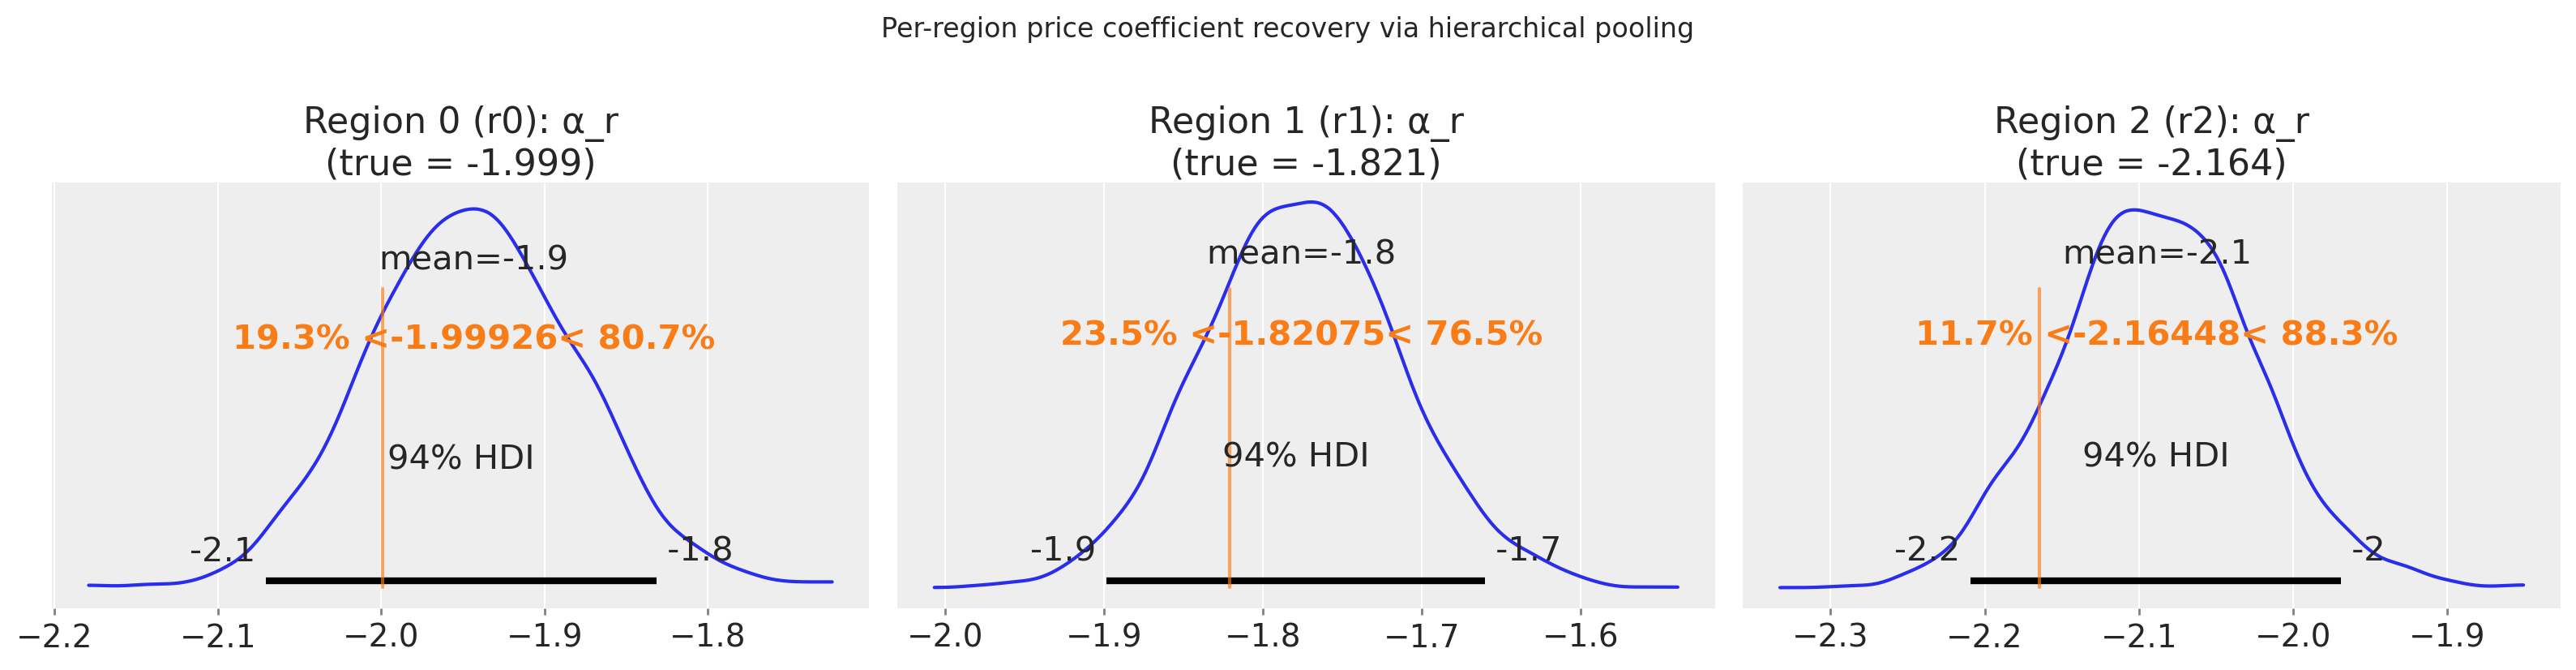

In [27]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

# Match the model's region ordering exactly
region_labels = (
    model_hier._regions
)  # or list(model_hier.idata.posterior.coords["region"].values)

for r, (ax, region_label, true_val) in enumerate(
    zip(axs, region_labels, truth_multi["alpha_r"], strict=True)
):
    az.plot_posterior(
        model_hier.idata,
        var_names=["alpha_r"],
        coords={"region": region_label},
        ref_val=float(true_val),
        ax=ax,
    )
    ax.set_title(f"Region {r} ({region_label}): α_r\n(true = {true_val:.3f})")

plt.suptitle("Per-region price coefficient recovery via hierarchical pooling", y=1.02)
plt.tight_layout()
plt.show()

In [28]:
# tau_alpha: between-region SD should be > 0 under genuine heterogeneity
tau_lo, tau_hi = az.hdi(
    model_hier.idata.posterior["tau_alpha"].values.ravel(), hdi_prob=0.94
)
print(f"tau_alpha 94% HDI: [{tau_lo:.3f}, {tau_hi:.3f}]")
print("tau_alpha lower bound > 0:", tau_lo > 0)

tau_alpha 94% HDI: [0.058, 0.900]
tau_alpha lower bound > 0: True


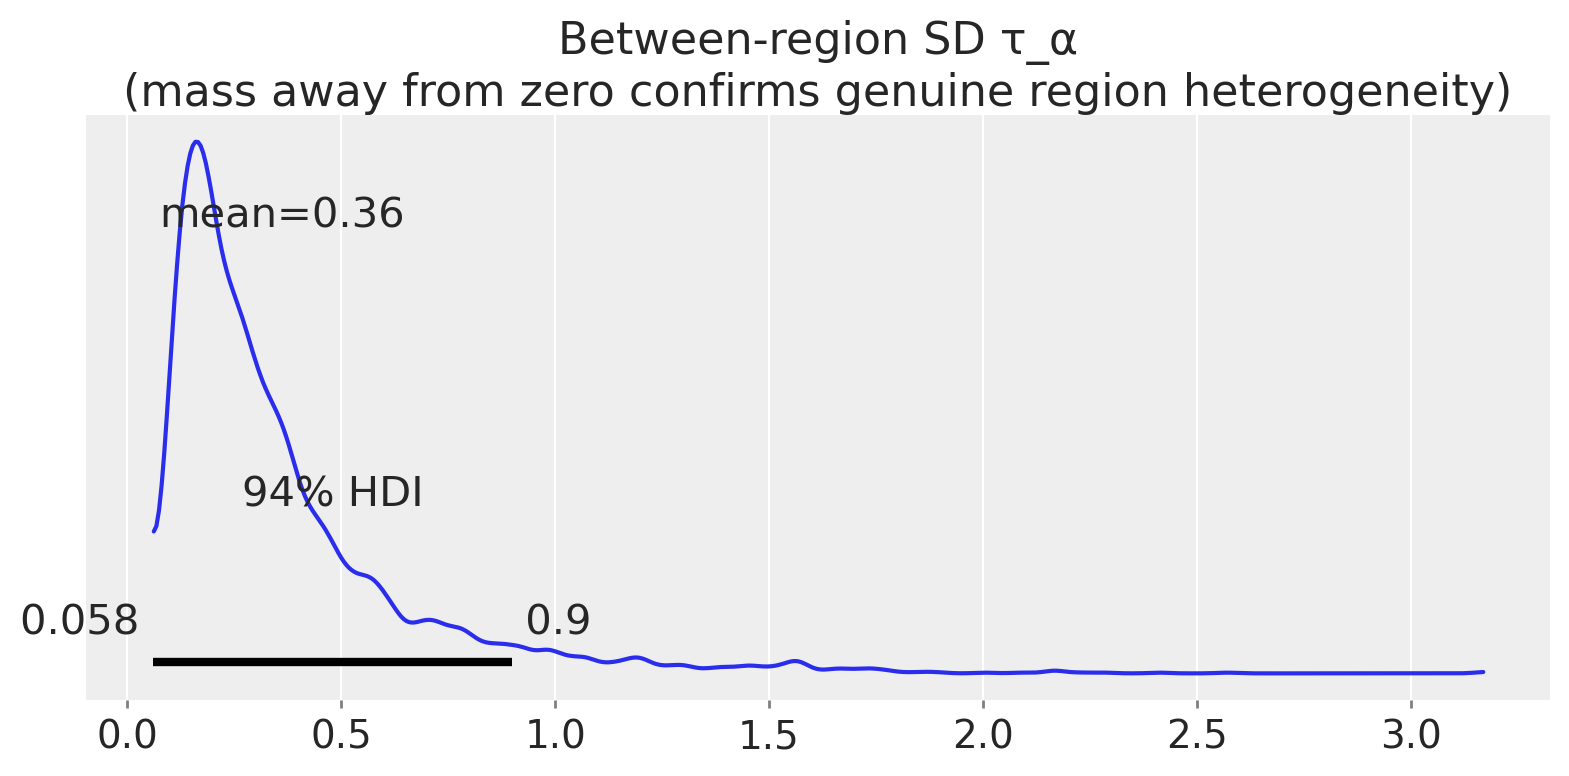

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
az.plot_posterior(model_hier.idata, var_names=["tau_alpha"], ax=ax)
ax.set_title(
    "Between-region SD τ_α\n(mass away from zero confirms genuine region heterogeneity)"
)
plt.tight_layout()
plt.show()

## 9. Interpreting the taste profiles

The model integrates over a population of consumer taste types to predict aggregate market shares. Having fit the posterior, we can reverse the question: **which taste types does each market rely on to generate its observed shares?** This is Bayesian backward inference, from aggregate patterns to latent consumer heterogeneity.

With three random coefficients each consumer type is a vector $\bm{\nu}_i = (\nu_{\text{price}}, \nu_{x_0}, \nu_{x_1})$. The stacked area chart below sorts consumers along $\nu_{\text{price}}$ only and so shows a *price-marginal* view: at each x-coordinate the other two taste dimensions vary across the Halton grid. The fully multi-dimensional buyer characterisation comes from the heatmap further down (Lens 1).


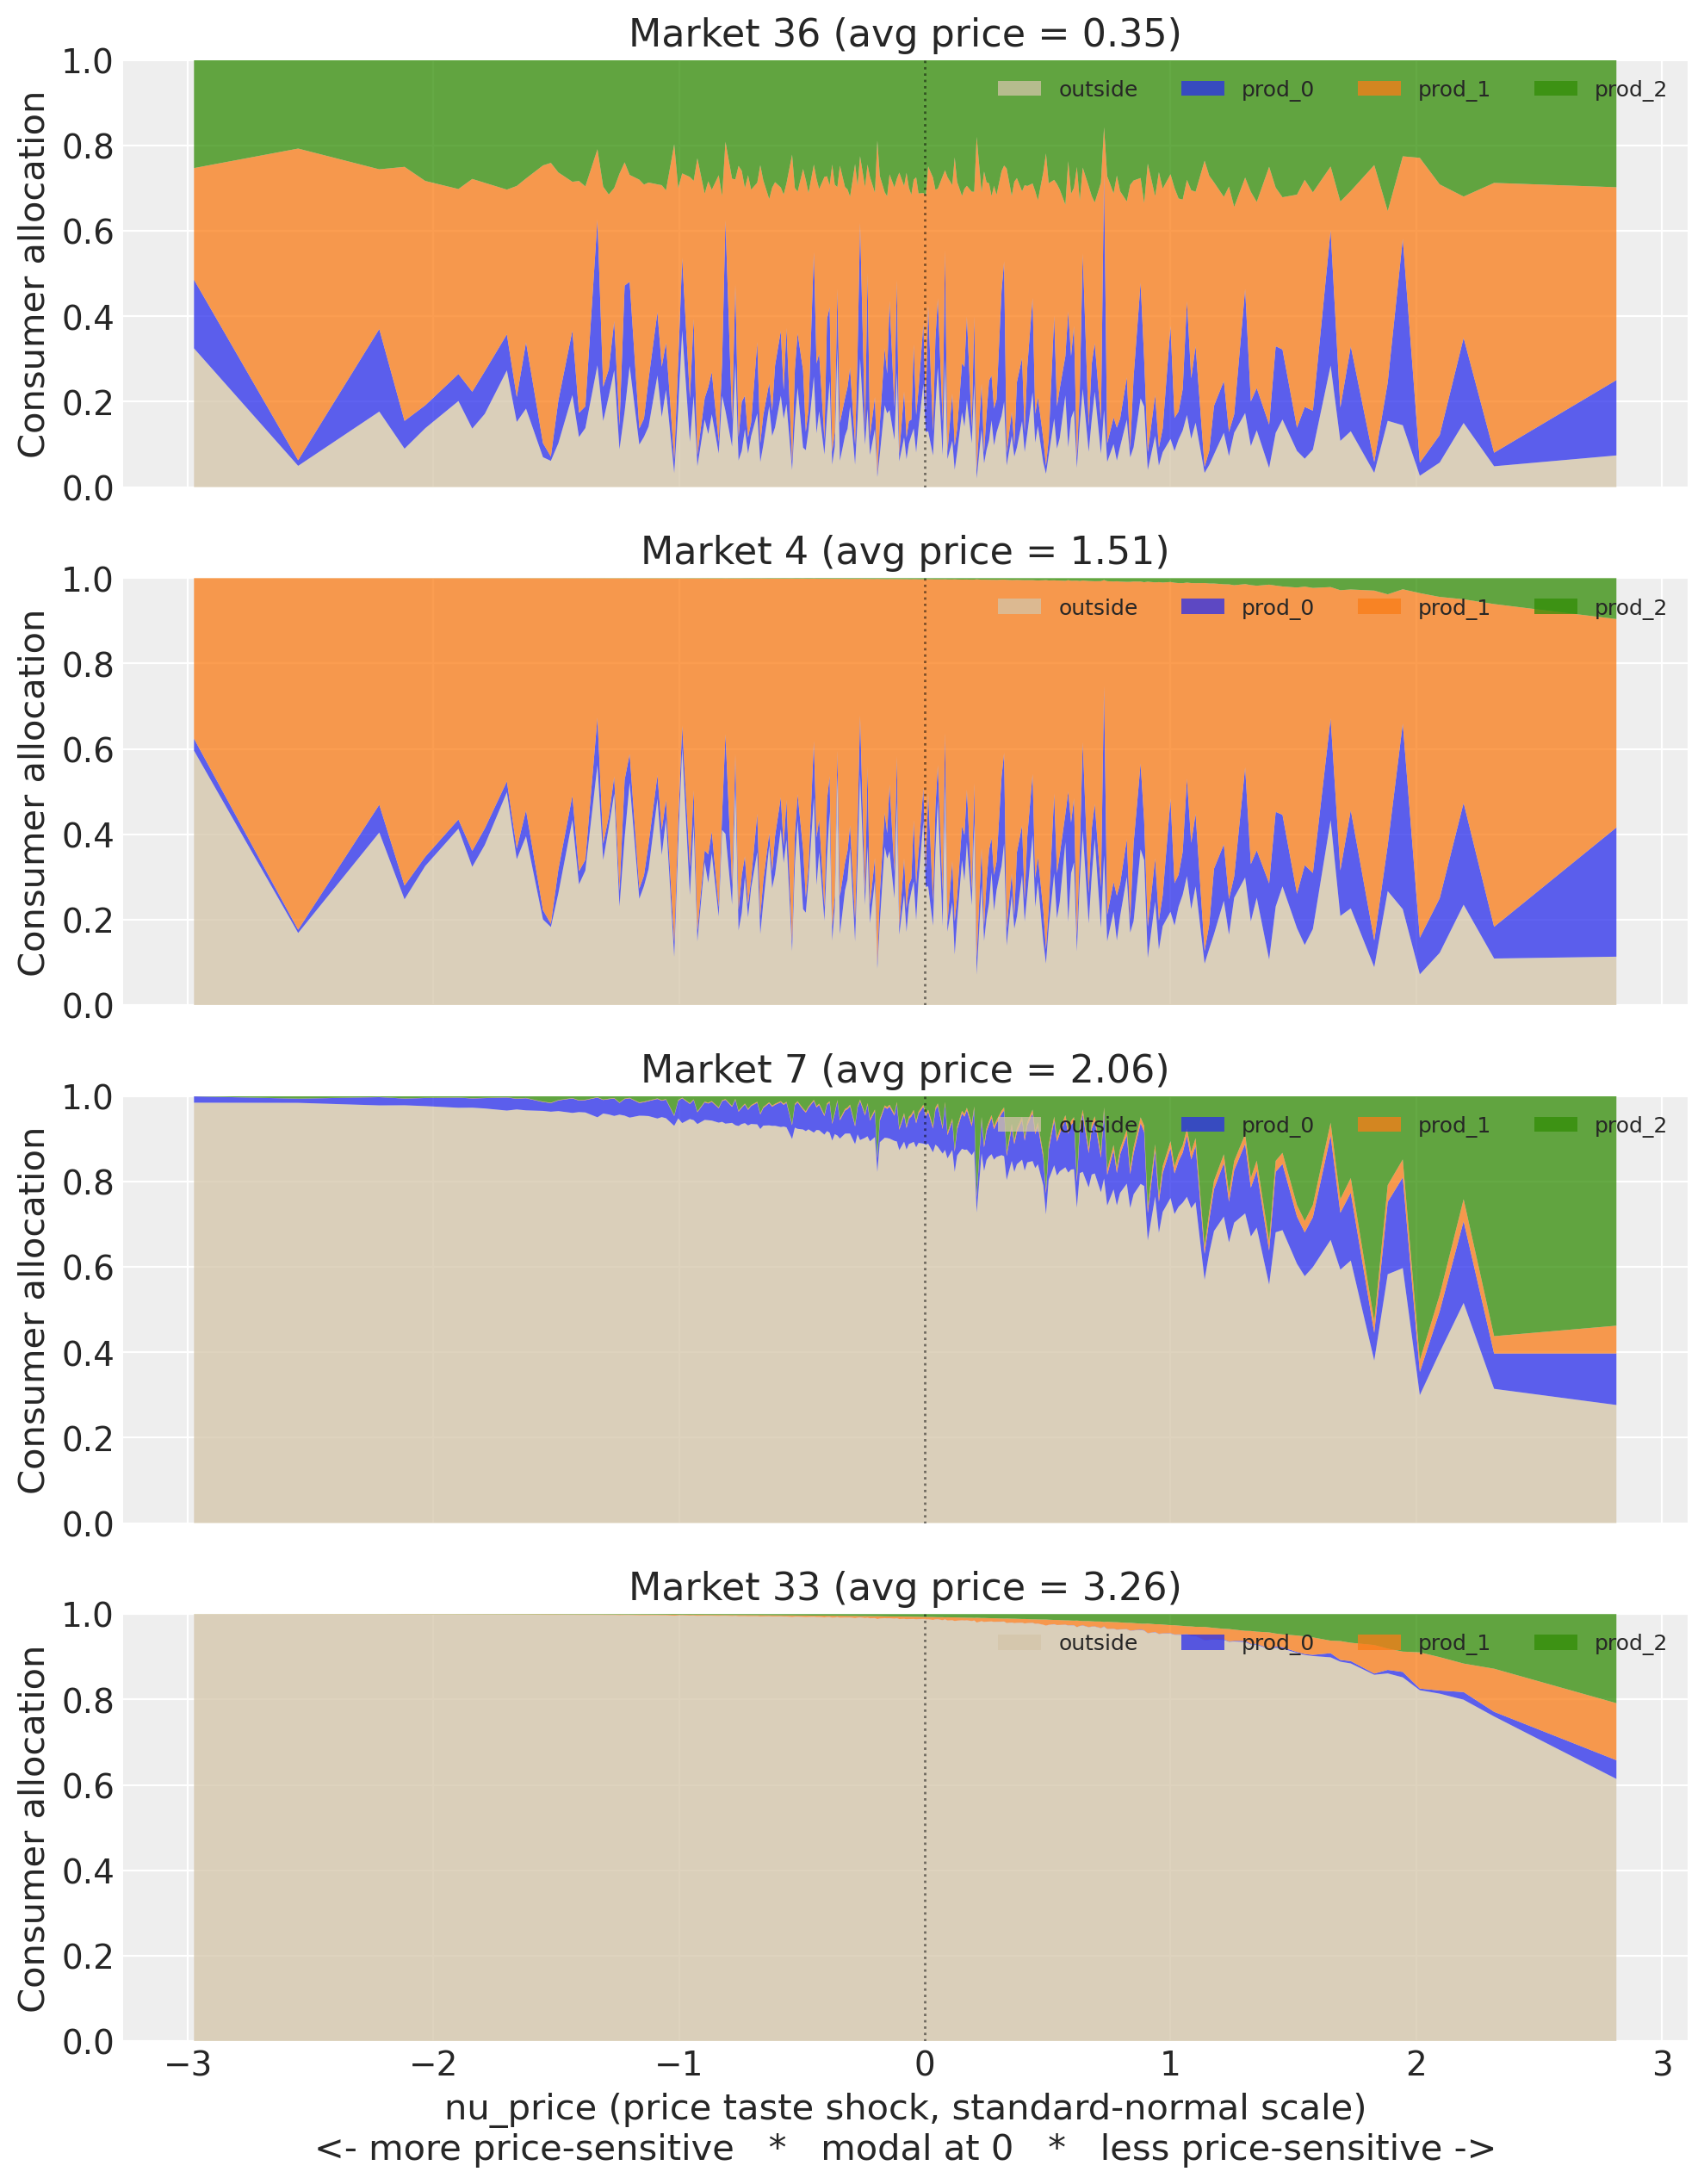

In [30]:
def plot_taste_profile_stacked(model, market_indices=None, n_samples=200):
    """Stacked area chart of consumer allocation across the nu_price axis.

    The outside good sits at the bottom; inside products are stacked above.
    Reading left to right: as nu increases (less price-sensitive), the outside
    band shrinks and the inside-product bands grow. Market-to-market differences
    in the transition shape reflect price-level and characteristic differences.
    """
    if market_indices is None:
        market_indices = list(range(min(4, model._M)))

    # Draw `n_samples` sets of (alpha, beta, xi, sigma) from the fitted posterior.
    # Each set defines a complete parameterisation of the demand model.
    alpha_M, beta_M, xi_M, sigma_M = model._iterate_posterior_samples(n_samples)

    # For each posterior draw, compute every Halton consumer's per-product
    # choice probability. Returns:
    #   s_per_draw    : (S, M, J, R) — choice prob per sample, market, product, consumer type
    #   s_out_per_draw: (S, M, R)    — outside-good prob per sample, market, consumer type
    s_per_draw, _, s_out_per_draw, *_ = model._batch_shares(
        alpha_M, beta_M, xi_M, sigma_M, model._price
    )

    # Average over posterior draws to get the expected allocation per consumer type.
    s_avg = s_per_draw.mean(axis=0)  # (M, J, R)
    s_out_avg = s_out_per_draw.mean(axis=0)  # (M, R)

    # The price taste shock for each Halton draw (already standard-normal).
    # nu < 0 = more price-sensitive, nu > 0 = less price-sensitive.
    nu = model._halton[: model.n_mc_draws, 0]
    order = np.argsort(nu)
    nu_sorted = nu[order]

    n = len(market_indices)
    _fig, axes = plt.subplots(n, 1, figsize=(10, 3.2 * n), sharex=True)
    if n == 1:
        axes = [axes]

    prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    outside_color = "#d4c5a9"
    inside_colors = prop_cycle[: model._J]

    for ax, m_idx in zip(axes, market_indices, strict=True):
        stacks = [
            s_out_avg[m_idx, order],
            *[s_avg[m_idx, j, order] for j in range(model._J)],
        ]
        labels = ["outside", *model._inside_products]
        colors = [outside_color, *inside_colors]
        ax.stackplot(
            nu_sorted, *stacks, labels=labels, colors=colors, alpha=0.75, zorder=1
        )

        ax.axvline(0, color="black", linestyle=":", lw=1, alpha=0.5)
        ax.set_ylim(0, 1)
        ax.set_ylabel("Consumer allocation")
        avg_p = float(model._price[m_idx].mean())
        ax.set_title(f"Market {model._markets[m_idx]} (avg price = {avg_p:.2f})")
        ax.legend(loc="upper right", ncol=model._J + 1, fontsize=9, framealpha=0.9)

    axes[-1].set_xlabel(
        "nu_price (price taste shock, standard-normal scale)\n"
        "<- more price-sensitive   *   modal at 0   *   less price-sensitive ->"
    )
    plt.tight_layout()
    plt.show()


# Span the price range: cheapest / low-mid / high-mid / most expensive
_avg_p = model._price.mean(axis=1)
_order = np.argsort(_avg_p)
_picks = [
    int(_order[0]),
    int(_order[len(_order) // 3]),
    int(_order[2 * len(_order) // 3]),
    int(_order[-1]),
]
plot_taste_profile_stacked(model, market_indices=_picks)

### Reading the results

**Market 36 (avg price 0.35): price has nothing to bite on.** The allocation bands run nearly flat across the entire $\nu$ axis. Even the most price-sensitive consumers (left edge) still buy inside goods; the outside good (grey) stays thin throughout. When everything costs 35 cents, choice is driven almost entirely by characteristics: prod_1 (orange) dominates, prod_2 (green) is second, prod_0 (blue) is a sliver. A flat logit would fit this market about as well.

**Market 4 (avg price 1.51): heterogeneity starts to matter.** The outside good grows noticeably on the left as price-sensitive types exit, and the transition is gradual. Prod_1 still dominates inside demand. The inside/outside split at $\nu = 0$ (the modal consumer) is roughly 60/40, so most consumers still participate. The slope from left to right tells you $\sigma_{\text{random}}$ is doing real work here: different taste types make meaningfully different choices.

**Market 7 (avg price 2.06): the cliff.** At $\nu < 0$ the market is almost entirely outside good. The inside products only emerge for $\nu > 0$, and prod_2 (green) overtakes prod_1 (orange) as the winner among insensitive types. This is the product-switching effect: prod_2 has better non-price characteristics, but you only see that once price sensitivity stops masking it. The modal consumer allocates ~95% to outside; this is a niche category at this price level.

**Market 33 (avg price 3.26): luxury niche.** The outside good fills nearly the entire chart until $\nu > 1.5$ (roughly the top 7% of the price-insensitivity distribution). Only the most extreme insensitive types buy inside goods at all, and even they split narrowly between prod_2 and prod_1. The demand-share table below will show this market drawing ~60%+ of its inside demand from insensitive consumers against a 16% population baseline.

**The cross-market story.** As average price rises from 0.35 to 3.26, the stacked area transforms from a flat rectangle (homogeneous, characteristics-driven) to a step function (only the insensitive tail participates), and the identity of the winning inside product flips from prod_1 to prod_2 along the way.


In [31]:
import pandas as pd


def taste_type_demand_share(model, n_samples=200):
    """Share of inside-good demand contributed by each taste-type bucket.

    Buckets by the price taste shock nu (already standard-normal):
      - price-sensitive:   nu < -1  (~16%% of population)
      - modal:            -1 <= nu <= 1  (~68%%)
      - price-insensitive: nu > 1   (~16%%)

    Under a homogeneous logit (sigma=0) every bucket would contribute in
    proportion to its population share: 16 / 68 / 16.  Deviations from
    that baseline reveal where heterogeneity matters.
    """
    # Draw posterior parameter sets, then compute per-consumer-type choice probs
    # (same mechanics as the stacked area chart above).
    alpha_M, beta_M, xi_M, sigma_M = model._iterate_posterior_samples(n_samples)
    s_per_draw, _, _, _, _ = model._batch_shares(
        alpha_M, beta_M, xi_M, sigma_M, model._price
    )

    # Collapse to (M, R): average over posterior draws AND products,
    # giving total inside-good demand per consumer type per market.
    s_avg = s_per_draw.mean(axis=(0, 2))  # (M, R)

    # Price taste shock per Halton draw (standard-normal; nu<0 = price-sensitive)
    nu = model._halton[: model.n_mc_draws, 0]
    sensitive = nu < -1.0
    insensitive = nu > 1.0
    modal = ~sensitive & ~insensitive

    rows = []
    for m in range(model._M):
        total = s_avg[m].sum()
        rows.append(
            {
                "market": model._markets[m],
                "avg_price": float(model._price[m].mean()),
                "sensitive_pct": s_avg[m, sensitive].sum() / total,
                "modal_pct": s_avg[m, modal].sum() / total,
                "insensitive_pct": s_avg[m, insensitive].sum() / total,
            }
        )
    return pd.DataFrame(rows)


profiles = taste_type_demand_share(model, n_samples=200)

# Baseline: under a flat logit the buckets contribute proportionally
nu = model._halton[: model.n_mc_draws, 0]
baseline = {
    "sensitive": (nu < -1).mean(),
    "modal": ((nu >= -1) & (nu <= 1)).mean(),
    "insensitive": (nu > 1).mean(),
}

print("Share of inside-good demand by taste-type bucket:\n")
print(profiles.to_string(index=False, float_format=lambda x: f"{x:6.3f}"))
print(f"\nHomogeneous baseline: {baseline}")

Share of inside-good demand by taste-type bucket:

 market  avg_price  sensitive_pct  modal_pct  insensitive_pct
      0      2.441          0.042      0.560            0.398
      1      2.078          0.097      0.674            0.228
      2      1.601          0.106      0.677            0.217
      3      0.993          0.151      0.676            0.173
      4      1.509          0.143      0.680            0.176
      5      1.358          0.117      0.687            0.196
      6      2.929          0.005      0.329            0.666
      7      2.064          0.039      0.569            0.393
      8      2.092          0.094      0.660            0.246
      9      2.510          0.025      0.525            0.450
     10      1.231          0.087      0.664            0.249
     11      1.602          0.116      0.641            0.243
     12      2.508          0.065      0.659            0.276
     13      1.064          0.146      0.681            0.173
     14      1.992 

### Who is the average inside-good buyer?

The bucketed table above answers "what fraction of the population at each $\nu$ band ends up buying inside?" Inverting the question gives a sharper summary: *given* that a consumer buys inside in market $m$, what is the posterior distribution of their full taste vector?

For each posterior sample $s$, market $m$, and random-coefficient dimension $d$,

$$
\bar\nu_{m,d}^{(s)} \;=\; \frac{\sum_r \nu_{r,d} \cdot s^{\text{in}}_{m,r}(s)}{\sum_r s^{\text{in}}_{m,r}(s)}
$$

where $s^{\text{in}}_{m,r}$ is the per-draw inside-good probability for consumer type $r$. The result is a posterior over the *average buyer's taste vector* in every market, with uncertainty inherited from $(\alpha, \sigma_\alpha, \beta, \sigma_\beta, \xi)$. Visualised as a `(market × dimension)` heatmap, each row of the heatmap is the three-component taste profile of a market's typical buyer.


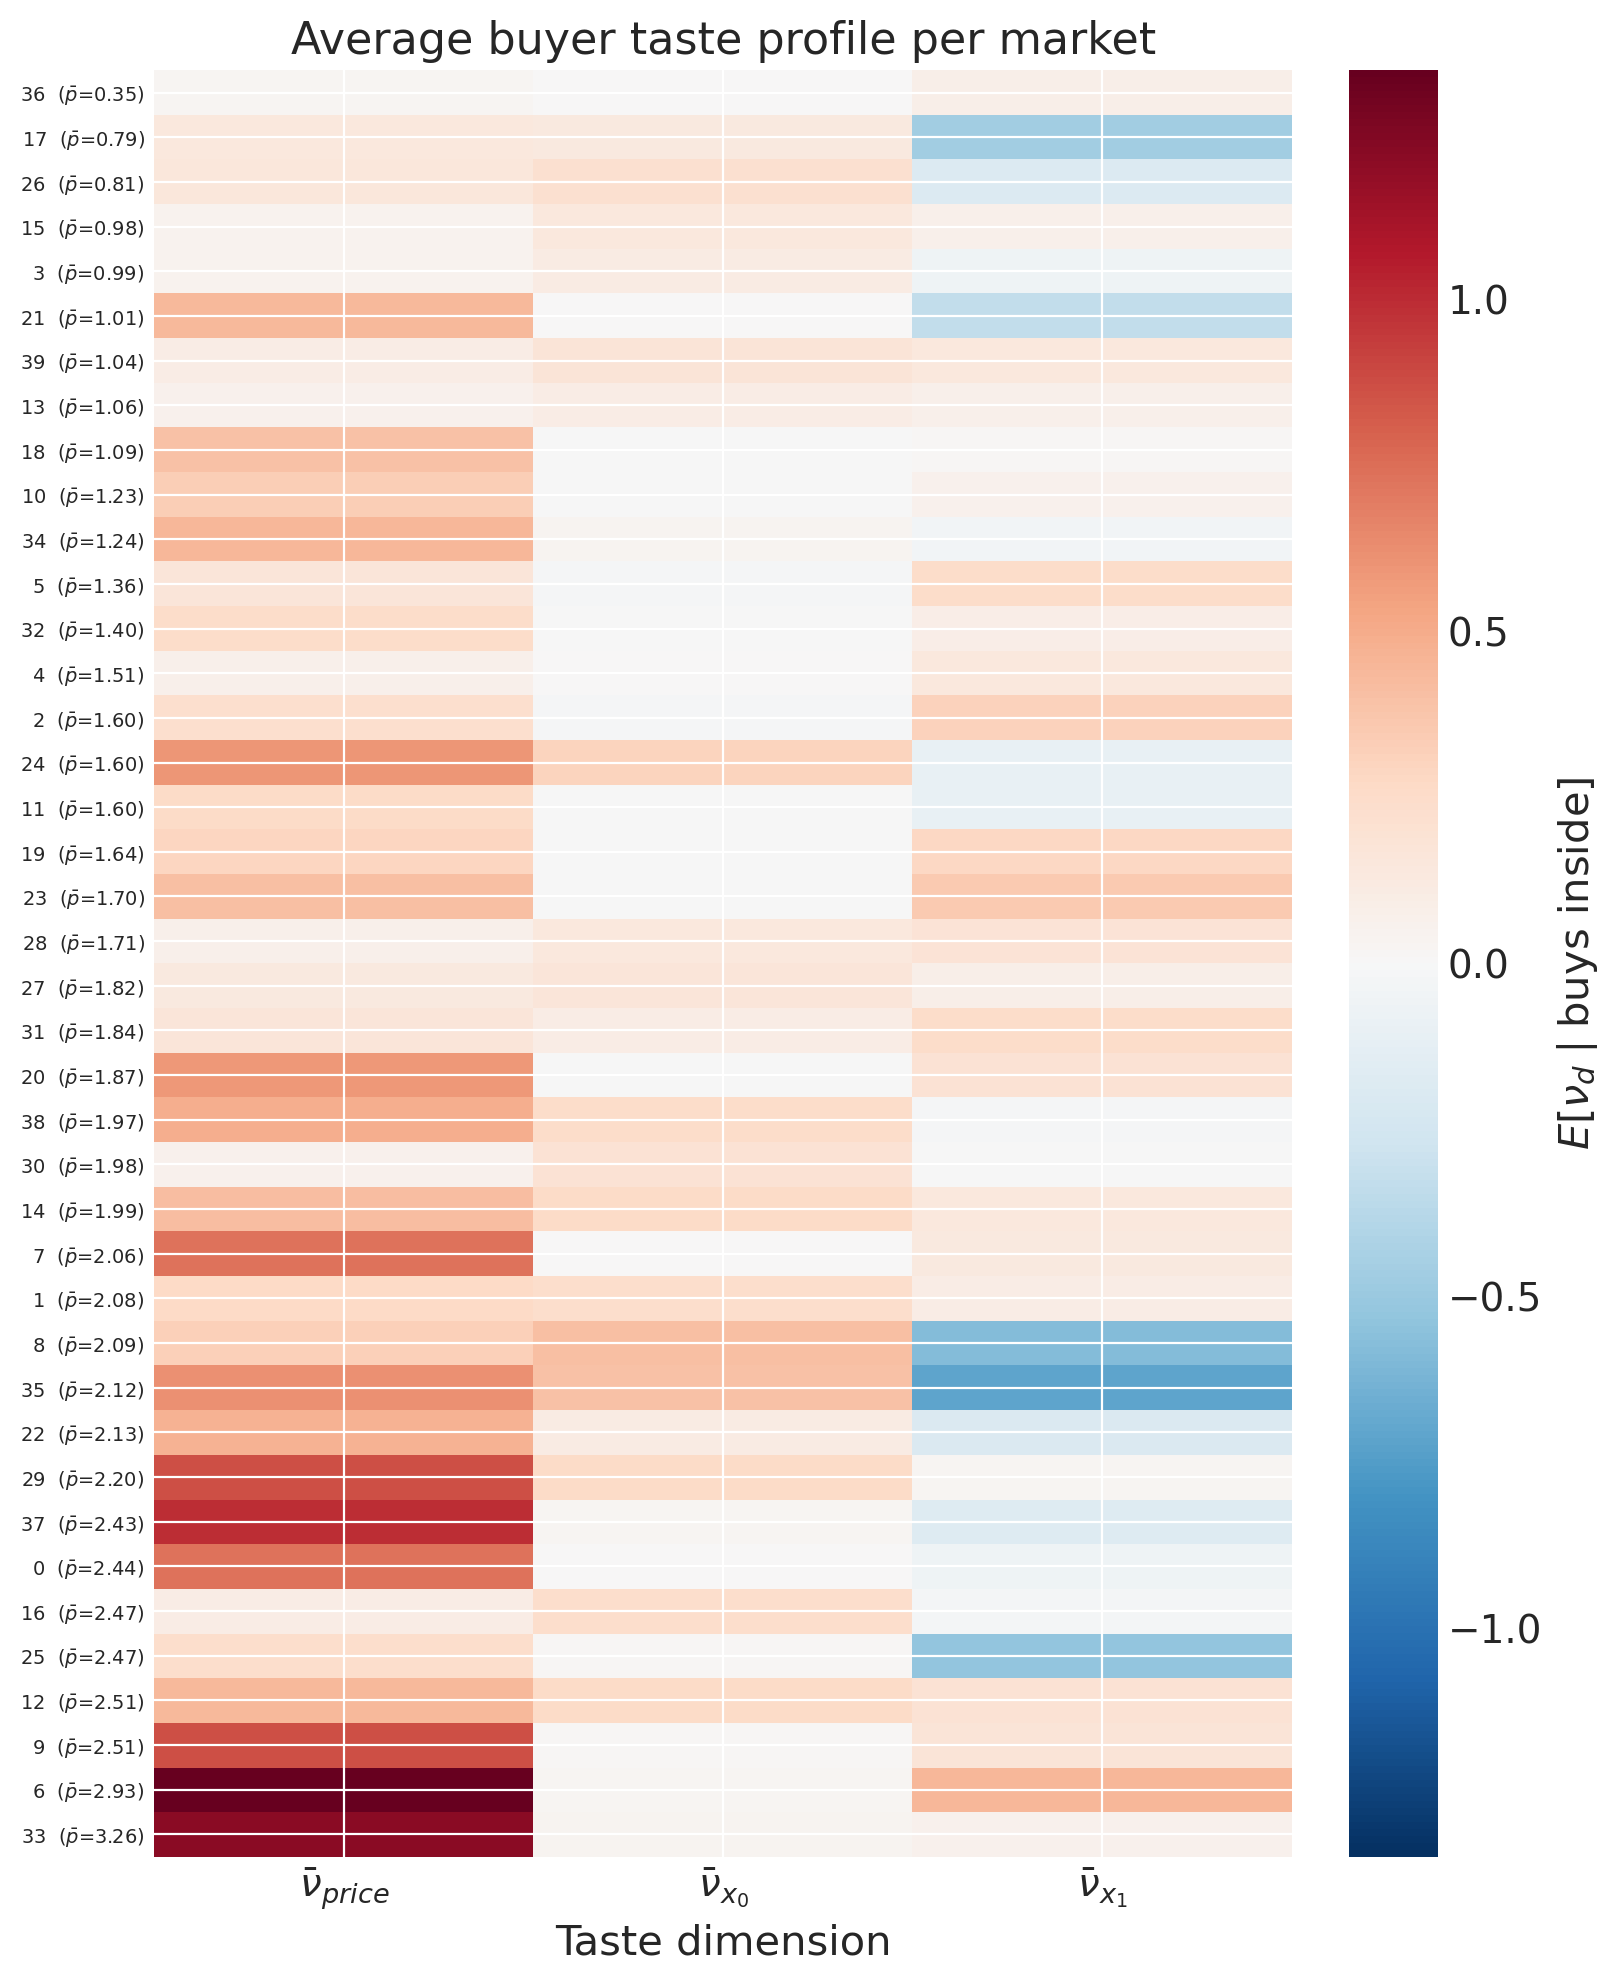

In [32]:
def buyer_nu_posterior_multi(model, n_samples=300):
    """Posterior of E[nu_d | buys inside] per (market, dimension).

    For each posterior sample s, market m, and dimension d:

        nu_bar[s, m, d] = sum_r nu[r, d] * s_inside[s, m, :, r].sum(j)
                          / sum_r s_inside[s, m, :, r].sum(j)

    Returns a (S, M, D) array of per-sample taste profiles.
    """
    alpha_M, beta_M, xi_M, sigma_M = model._iterate_posterior_samples(n_samples)
    s_in_per_draw, *_ = model._batch_shares(
        alpha_M, beta_M, xi_M, sigma_M, model._price
    )  # (S, M, J, R)
    s_in_total = s_in_per_draw.sum(axis=2)  # (S, M, R)
    nu = model._halton[: model.n_mc_draws]  # (R, D)
    # einsum: weight nu[r, d] by s_in_total[s, m, r], sum over r.
    weighted = np.einsum("smr,rd->smd", s_in_total, nu)
    total = s_in_total.sum(axis=2, keepdims=True)  # (S, M, 1)
    return weighted / np.maximum(total, 1e-30)


nu_bar = buyer_nu_posterior_multi(model, n_samples=300)  # (S, M, D)
market_avg_price = model._price.mean(axis=1)
order = np.argsort(market_avg_price)

mean_profile = nu_bar.mean(axis=0)  # (M, D)
heatmap = mean_profile[order]

D = model._halton.shape[1]
fig, ax = plt.subplots(layout="constrained", figsize=(2 + 2 * D, 0.22 * model._M + 1))
vmax = float(np.abs(mean_profile).max())
im = ax.imshow(heatmap, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(D))
ax.set_xticklabels([rf"$\bar\nu_{{{n}}}$" for n in model._random_coef_names])
ax.set_yticks(range(len(order)))
ax.set_yticklabels(
    [f"{model._markets[i]}  ($\\bar p$={market_avg_price[i]:.2f})" for i in order],
    fontsize=7,
)
ax.set_title("Average buyer taste profile per market")
ax.set_xlabel("Taste dimension")
plt.colorbar(im, ax=ax, label=r"$E[\nu_d \mid \mathrm{buys\ inside}]$")
plt.show()

Each row is a market sorted by avg price; each column is one of the three taste dimensions. Red cells mean buyers in that market score *above-modal* on that taste dimension (so insensitive to price, or with a strong positive preference for the characteristic). Blue cells mean *below-modal* buyers (price-sensitive, or aversive to the characteristic).

A market with a uniform red row is served by consumers who are above-modal on every dimension. A market with mixed colours is served by buyers who are insensitive on one dimension but average on another. This is the multi-dimensional analogue of the scalar "average buyer $\nu$" picture: instead of saying "this market is served by price-insensitive consumers", we now say "this market is served by consumers who are price-insensitive *and* high-$x_0$ preference *and* average on $x_1$".

The price dimension still tracks market price (cheaper markets pull buyers in from the price-sensitive side); the $x_0$ and $x_1$ dimensions reveal substitution patterns the scalar lens hid.


### How concentrated is the demand?

A second question naturally follows: even within a market, is inside-good demand spread across all consumer types, or carried by a narrow slice?

For each (sample, market) we compute the Gini coefficient of the per-consumer-type contributions $s^{\text{in}}_{m,r}$:

$$
G_m^{(s)} \;=\; \frac{\sum_{r,r'} |s^{\text{in}}_{m,r} - s^{\text{in}}_{m,r'}|}{2 R \sum_r s^{\text{in}}_{m,r}}
$$

$G_m = 0$ means every consumer type contributes the same amount (broadly served market); $G_m \to 1$ means one type carries almost all the demand (niche market).


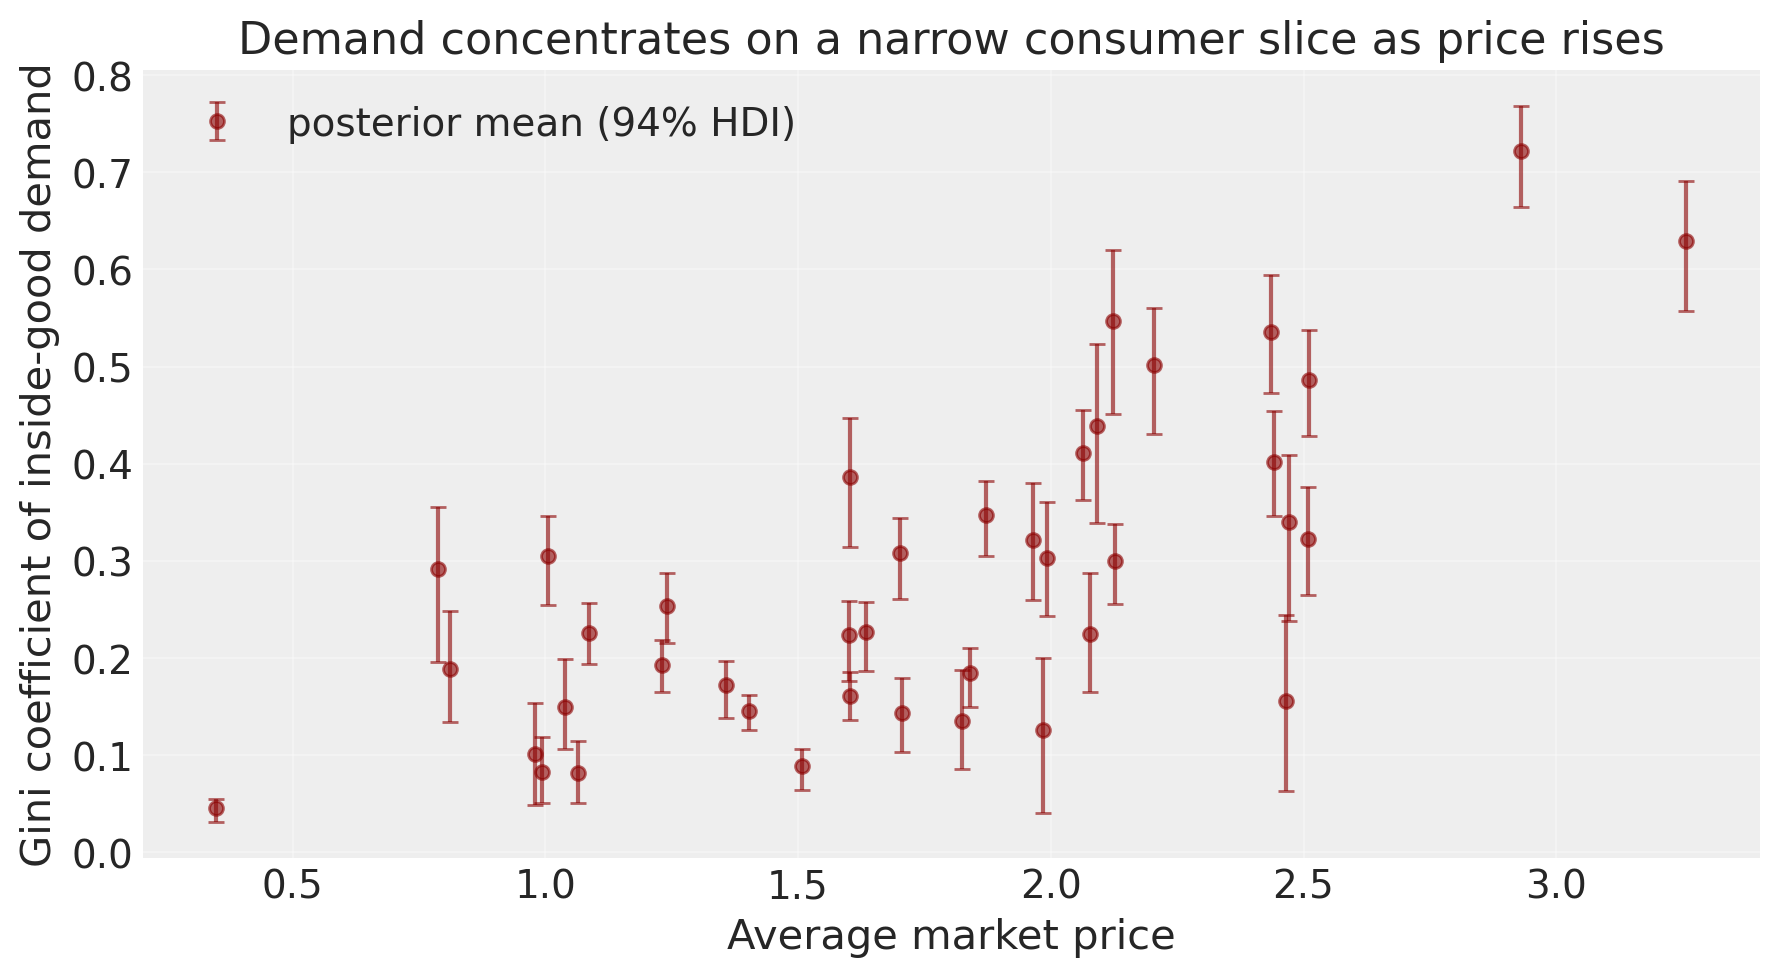

In [33]:
def demand_concentration_gini(model, n_samples=300):
    """Gini coefficient of inside-good demand across consumer types, per market.

    Returns (S, M) array of per-sample Gini values.
    """
    alpha_M, beta_M, xi_M, sigma_M = model._iterate_posterior_samples(n_samples)
    s_in_per_draw, *_ = model._batch_shares(
        alpha_M, beta_M, xi_M, sigma_M, model._price
    )  # (S, M, J, R)
    s_in_total = s_in_per_draw.sum(axis=2)  # (S, M, R)
    R = s_in_total.shape[2]
    sorted_vals = np.sort(s_in_total, axis=2)
    weights = 2 * np.arange(1, R + 1) - R - 1
    return (sorted_vals * weights).sum(axis=2) / (
        R * np.maximum(sorted_vals.sum(axis=2), 1e-30)
    )


gini = demand_concentration_gini(model, n_samples=300)
g_mean = gini.mean(axis=0)
g_lo, g_hi = np.percentile(gini, [3, 97], axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    market_avg_price,
    g_mean,
    yerr=[g_mean - g_lo, g_hi - g_mean],
    fmt="o",
    color="darkred",
    alpha=0.6,
    capsize=3,
    markersize=5,
    label="posterior mean (94% HDI)",
)
ax.set_xlabel("Average market price")
ax.set_ylabel("Gini coefficient of inside-good demand")
ax.set_title("Demand concentrates on a narrow consumer slice as price rises")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

As average price rises, the Gini climbs from near zero to roughly 0.7. At low prices every consumer type buys inside in similar proportion, so demand is uniformly spread (low Gini). At high prices only the insensitive tail buys, so demand concentrates on a thin slice of consumer types (high Gini). The two lenses tell complementary stories: $\bar\nu_m$ says *where* on the $\nu$ axis the buyers sit; the Gini says *how tightly* they cluster there.


## 10. Summary

In this notebook we demonstrated the full BayesianBLP workflow:

1. **Data generation** — `generate_blp_panel` with endogenous prices and known truth.
2. **Prior predictive check** — shares sum to 1; priors cover plausible scanner data.
3. **IV fit** — zero divergences; posterior recovers `α`, `β`, `σ_α` inside the 94% HDI.
4. **Endogeneity bias** — dropping instruments biases `α` toward zero by `≈0.16`;
   instruments correct this.
5. **Elasticities** — own-price negative (−3 to −5 range); cross-price positive;
   full posterior uncertainty available.
6. **Counterfactual** — a 10% price hike on one product reduces its share,
   raises rivals and the outside good, with calibrated posterior uncertainty.
7. **Price sensitivity** — implied taste profiles per market


In [34]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing

Last updated: Mon May 25 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.8.0

pymc_marketing: 0.19.3

pymc_marketing: 0.19.3
scipy         : 1.16.3
numpy         : 2.3.5
pandas        : 2.3.3
seaborn       : 0.13.2
arviz         : 0.23.0
matplotlib    : 3.10.8

Watermark: 2.5.0

